# Configuration

In [1]:
import os 
import pickle

if True ^ os.getcwd().endswith("winners-curse"):
    os.chdir('..')

from typing import Iterable, Union
from joblib import Parallel, delayed

In [2]:
import random
import pandas as pd 
import numpy as np

from tqdm import tqdm

from scipy.special import expit
from sklearn.linear_model import LogisticRegression, Lasso 

In [3]:
# visualization
import matplotlib.pyplot as plt
import seaborn as sns

# visualization params
# label size
tick_label_size = 12
legend_label_size = 12
axis_label_size = 14
title_size = 18
# font
plt.rcParams['font.family'] = 'serif'

# model label map 
model_label_map = {
    'plugin': 'Plugin', 
    'standard_bootstrap': 'Standard Bootstrap', 
    'mn_bootstrap': 'm-out-of-n Bootstrap', 
    'num_bootstrap': 'Numerical Bootstrap'
}

In [4]:
from core.dgp import DataGenerationProcess, Targeting
from core.targeting import *
from core.variables import *

# DGP

In [25]:
dgp_params = {
    'base_effect_vars': [PointMass(1 + i * 0.1) for i in range(2)], 
    'cust_feat_var': UnivariateGaussian(0, 1), 
    'char_func': lambda x: x**2 + x, 
    'noise_var': UnivariateGaussian(0, 1), 
    'response_type': 'continuous', 
    'dgp_seed': 0
}

# dgp_params = {
#     'base_effects': [PointMass(0.1), PointMass(0.11)], 
#     'cust_feat_var': Uniform(0, 1), 
#     'char_func': lambda x: x**2 + x, 
#     'response_type': 'bernoulli', 
#     'dgp_seed': 0
# }

# instantiate the DGP
dgp = Targeting(**dgp_params)

In [26]:
# sample 
cust_features, treatments, outcomes = dgp.sample(5000)
oos_cust_features = dgp.sample_individuals(1000)

# Estimation

In [27]:
cfdml = CausalForestDML(
    n_treatments=2, model_t=LogisticRegression(C=0.01), model_y=Lasso(alpha=0.01), 
    n_estimators=100, max_depth=30, n_jobs=-1, discrete_treatment=True
).fit(X=cust_features, Y=outcomes, T=treatments)

emp_targ_te_arr, emp_targ_var_arr = cfdml.predict_incremental_effect(oos_cust_features)

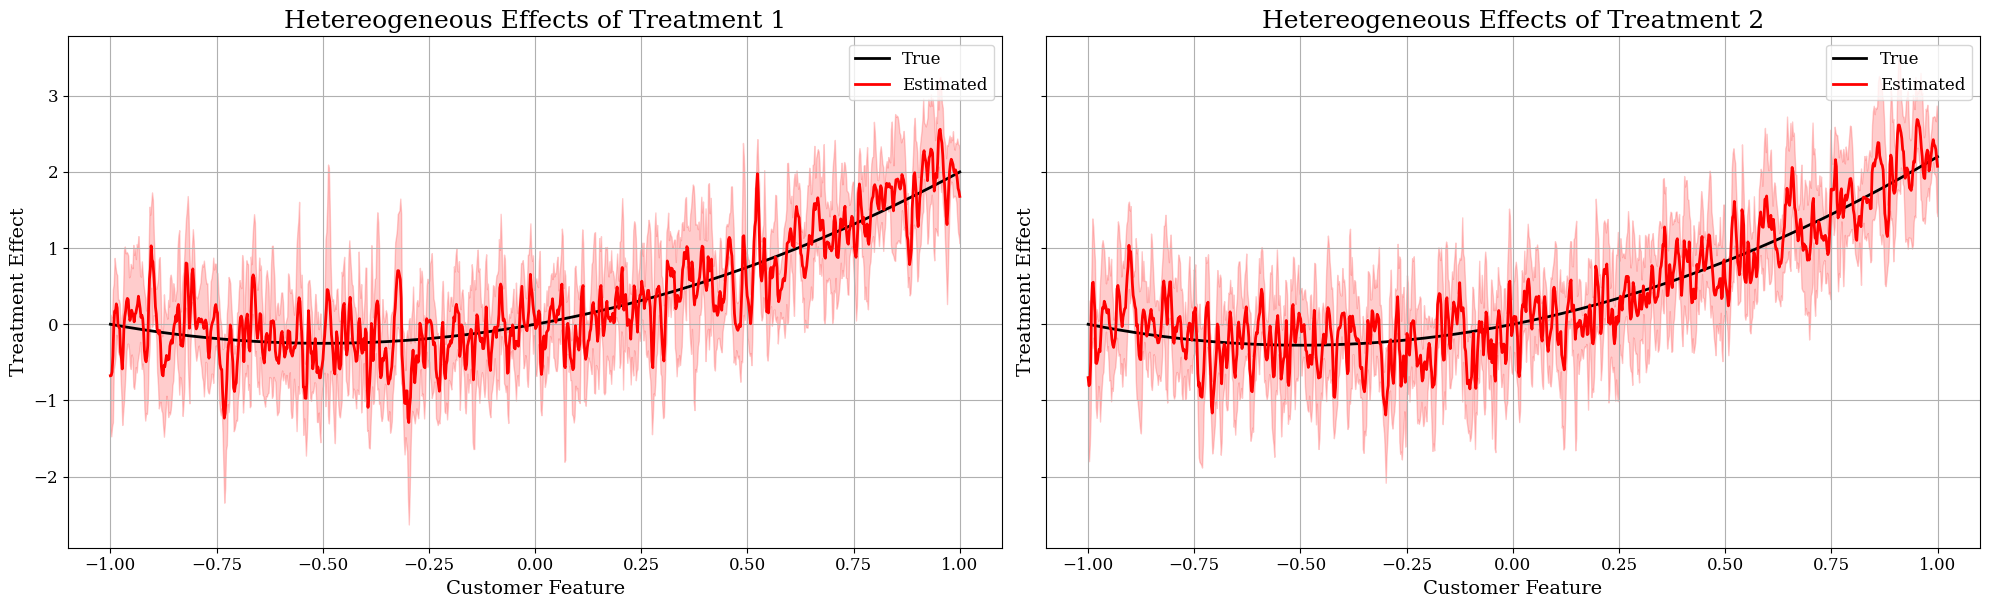

In [28]:
plot_hte(dgp, model=cfdml, ci=True)


Max_depth = 2
Average variance = 0.05446289857803355


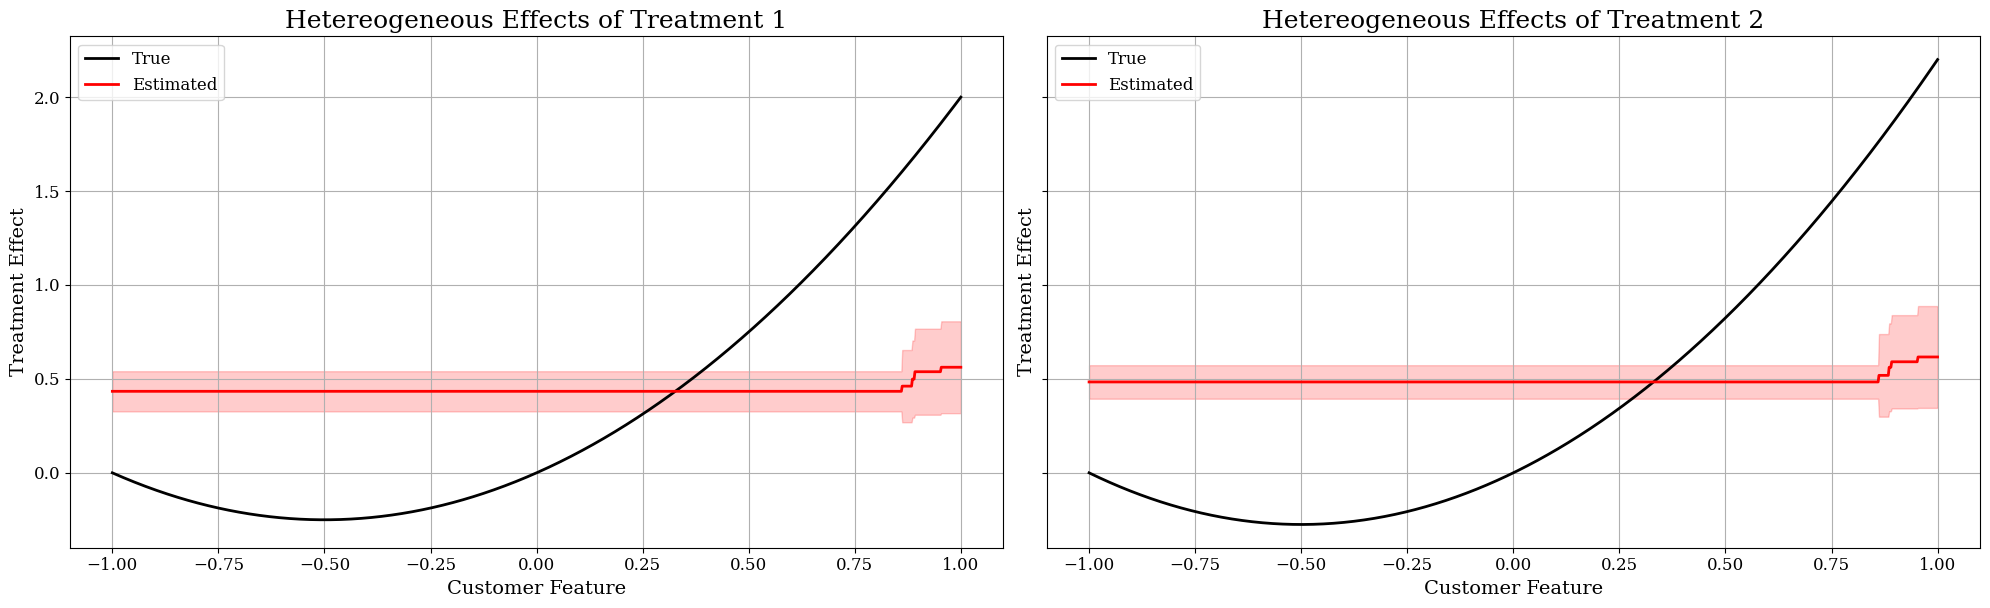


Max_depth = 3
Average variance = 0.04856137534609074


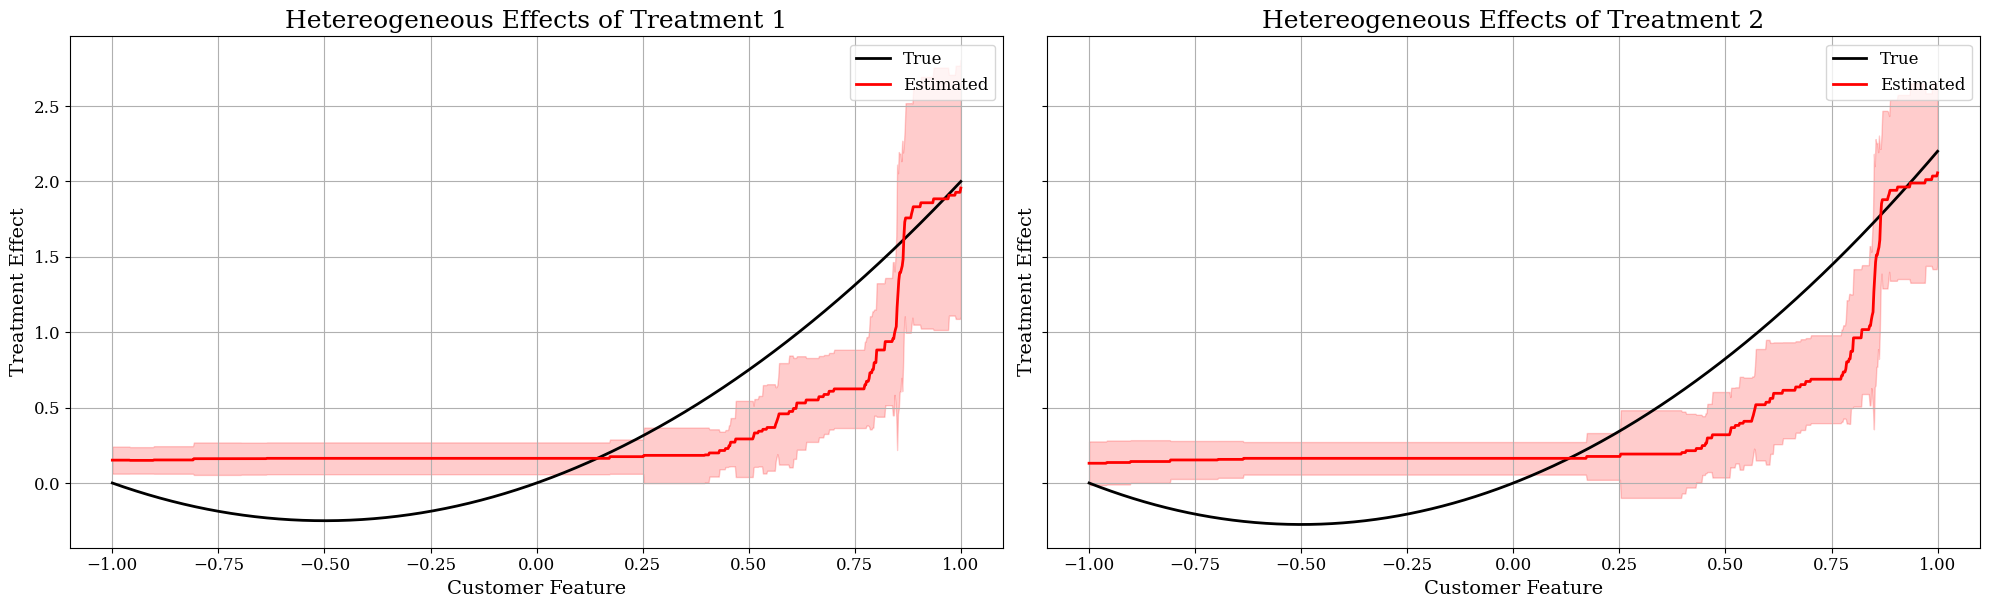


Max_depth = 4
Average variance = 0.03498752514784196


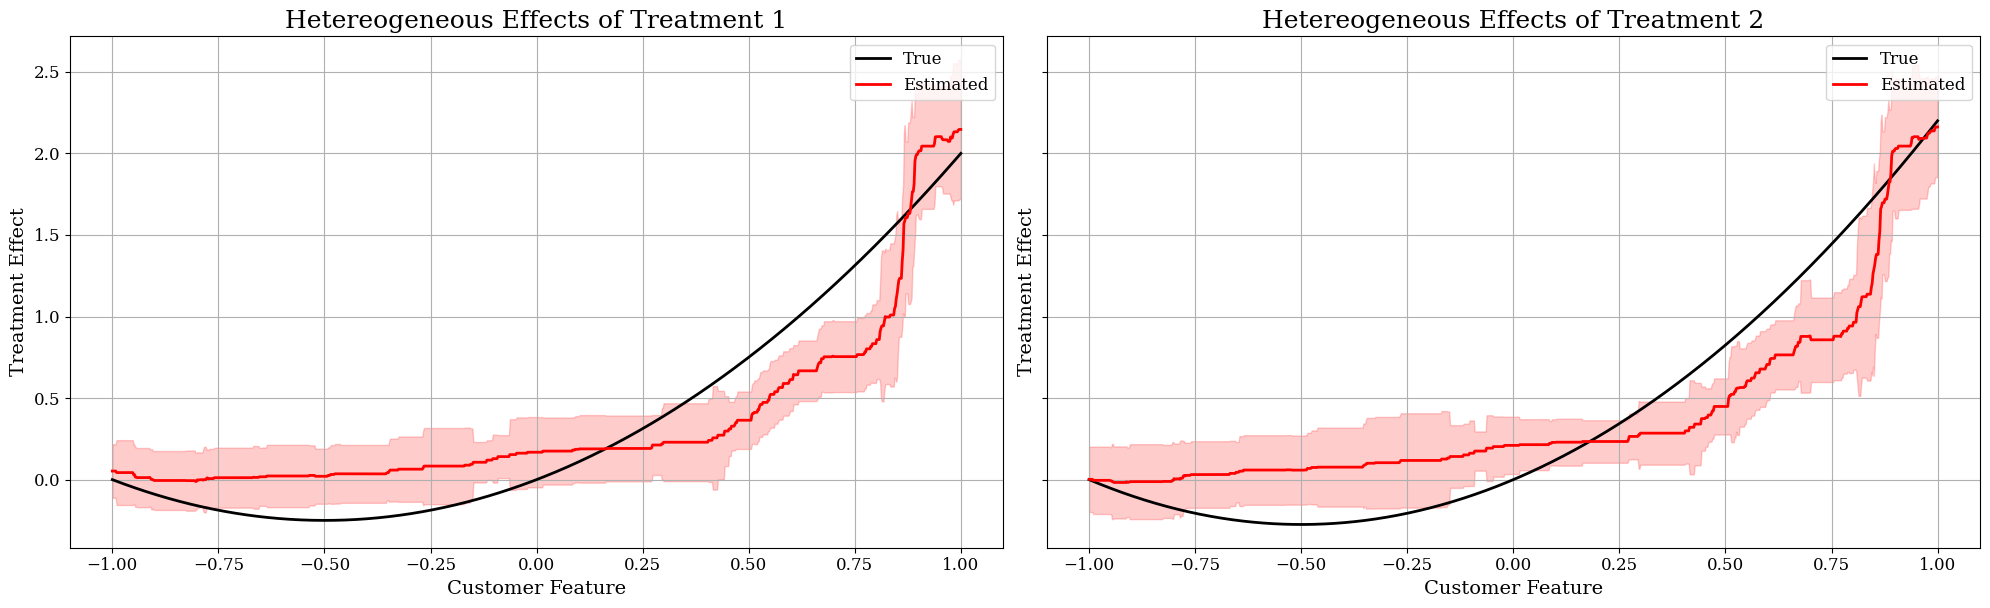


Max_depth = 5
Average variance = 0.03836469931669053


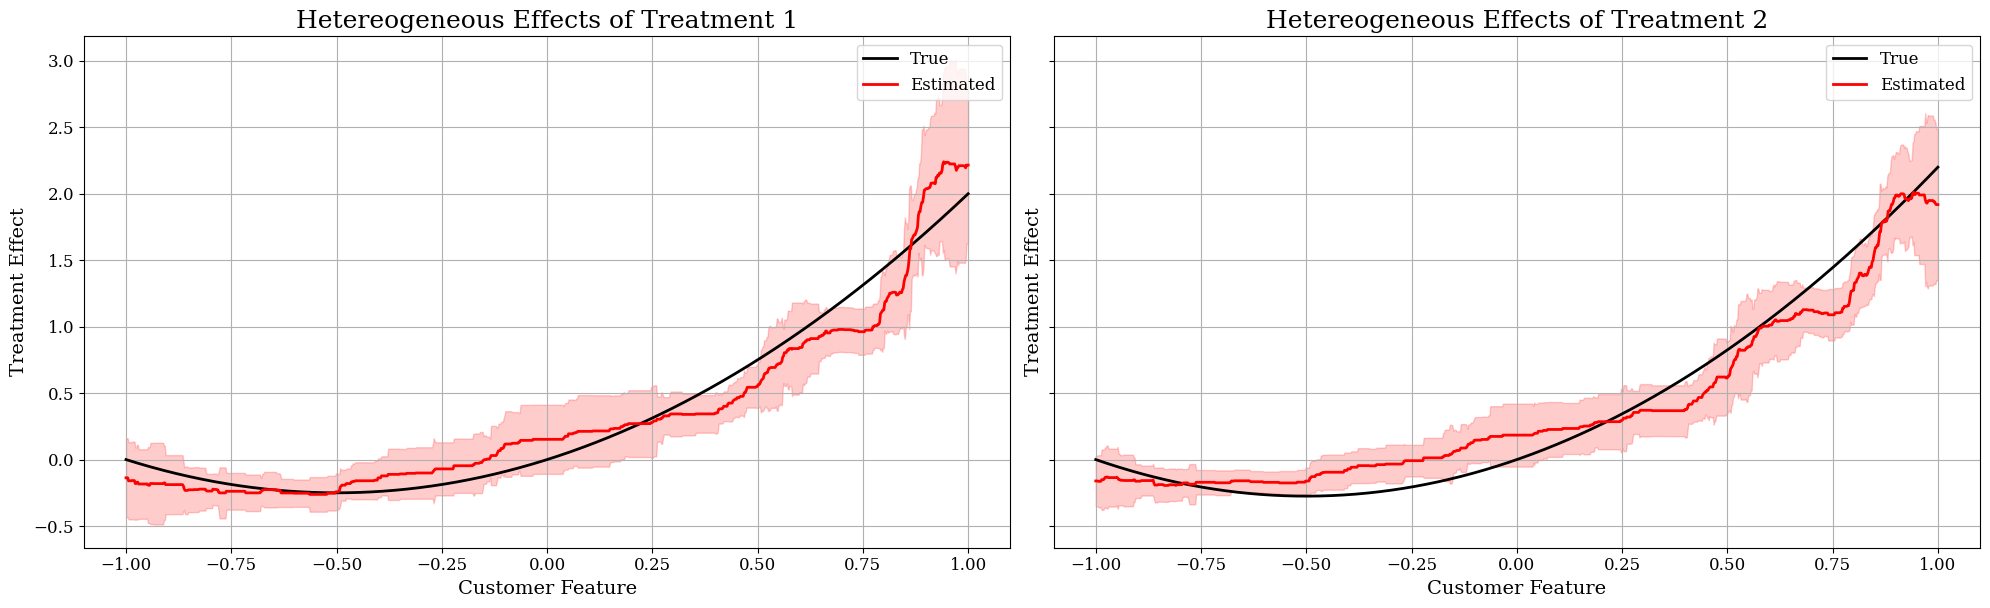


Max_depth = 6
Average variance = 0.051329149838438094


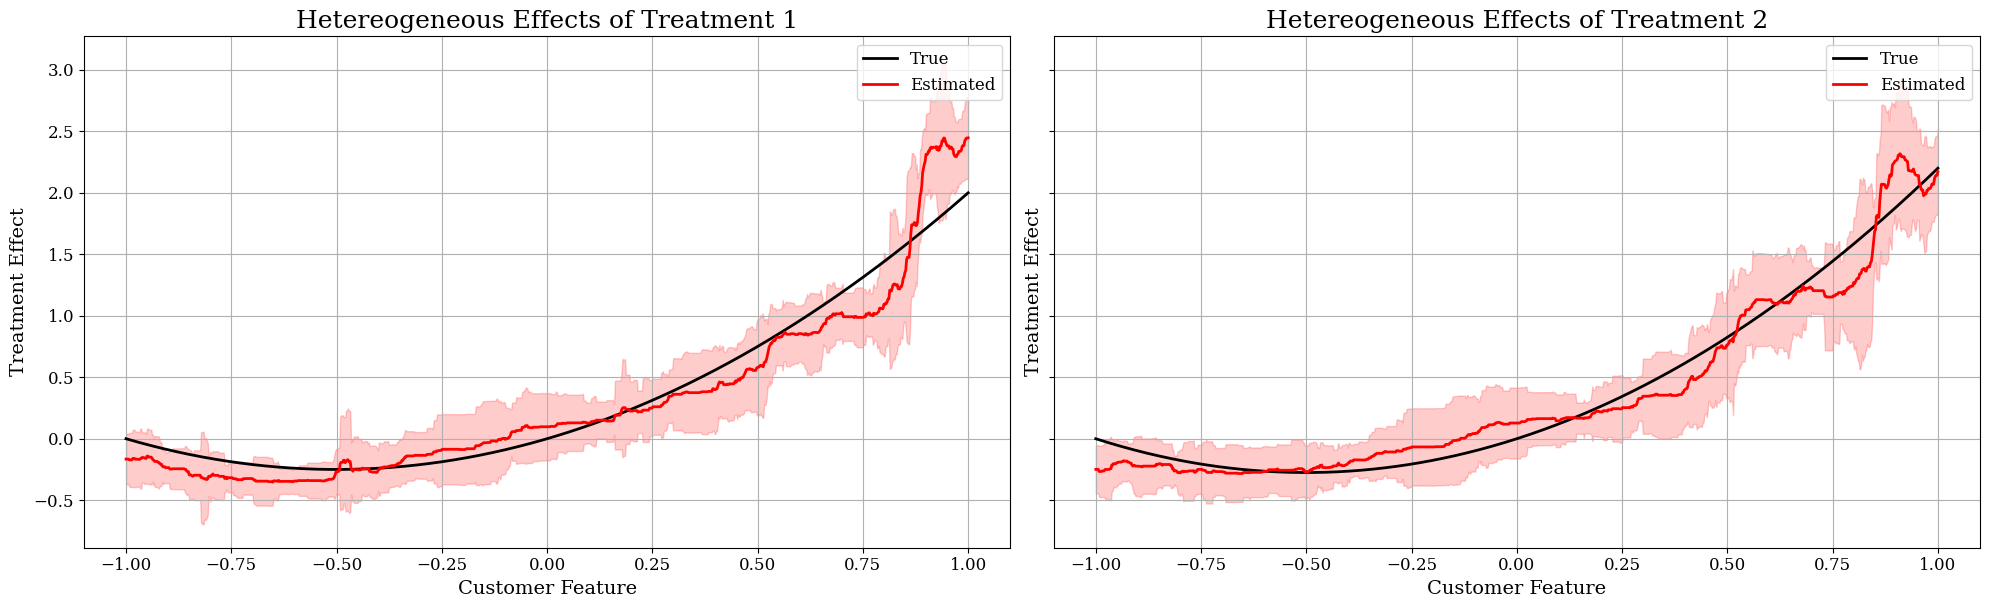


Max_depth = 7
Average variance = 0.054449377656358225


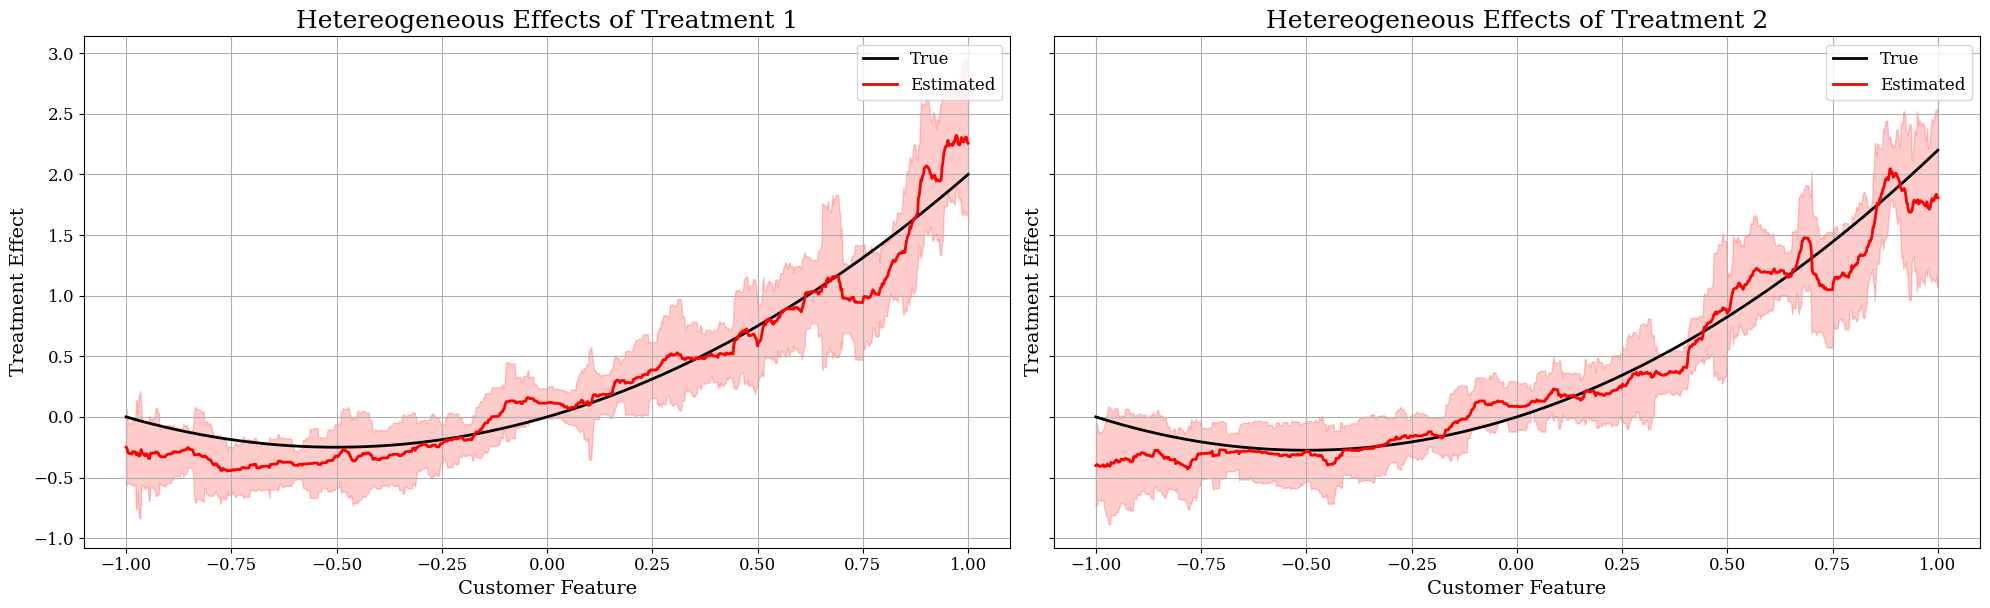


Max_depth = 8
Average variance = 0.06223960822047885


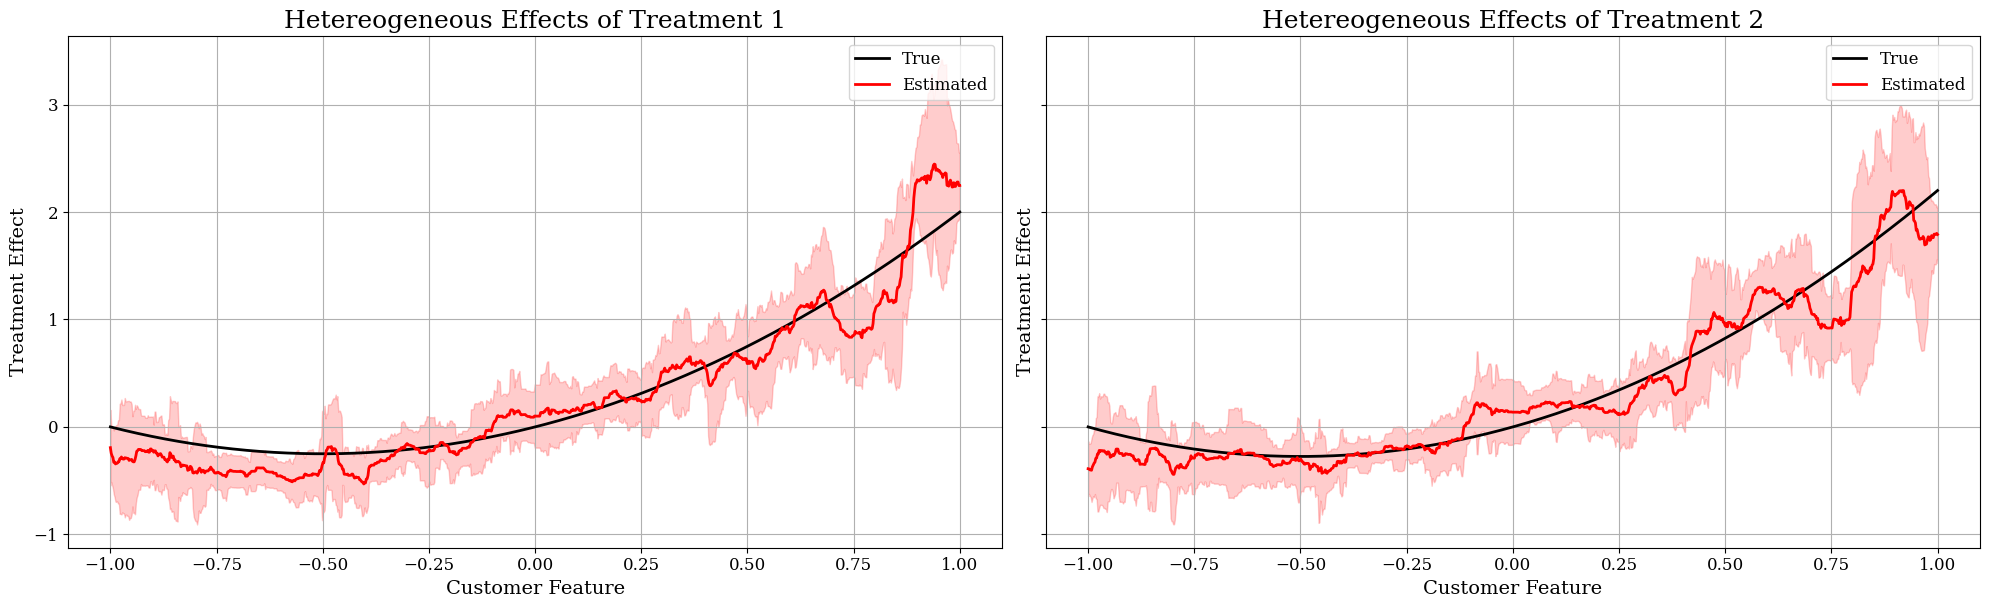


Max_depth = 9
Average variance = 0.07780533250303832


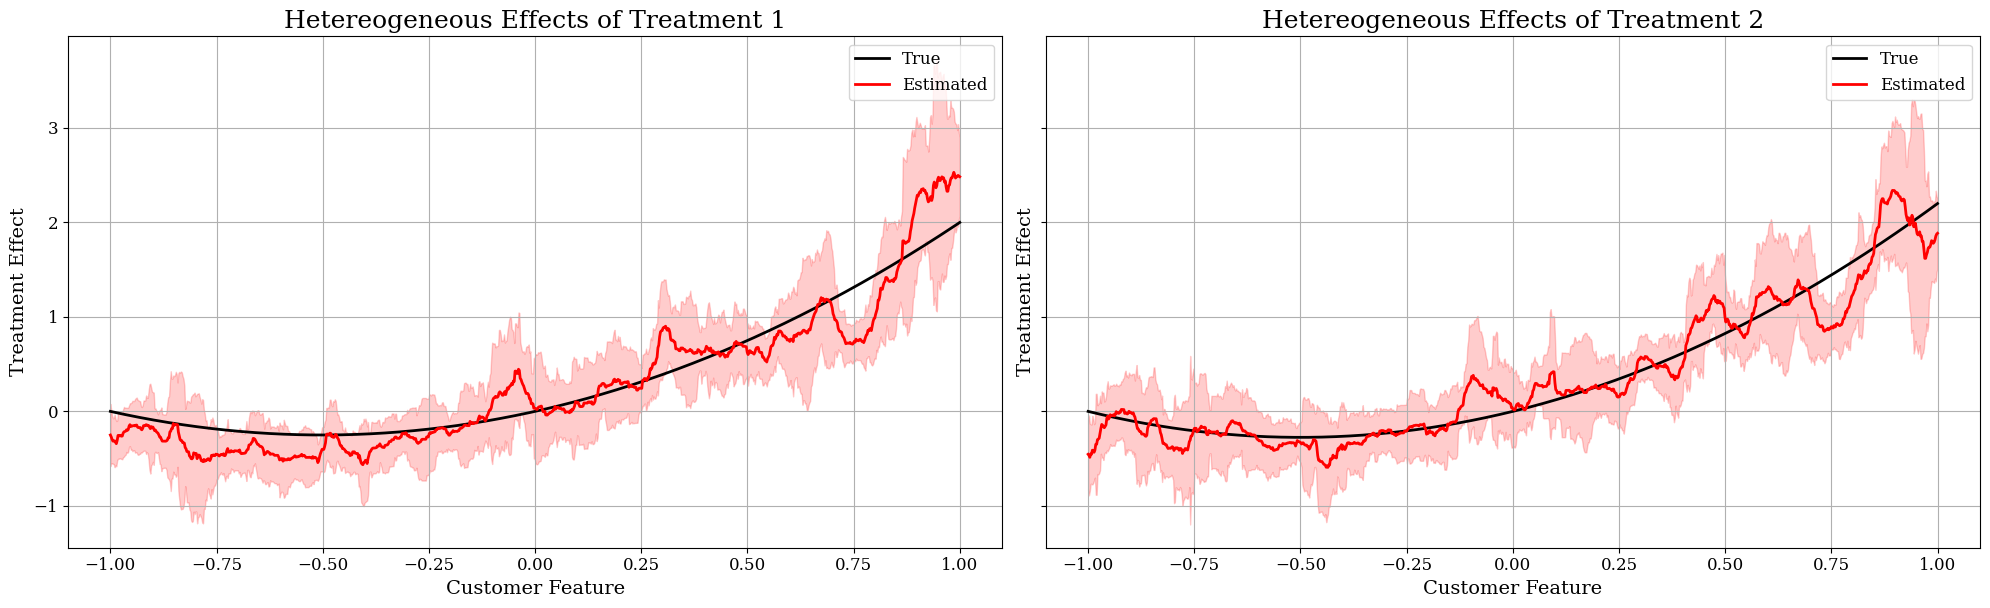


Max_depth = 10
Average variance = 0.09713303083549875


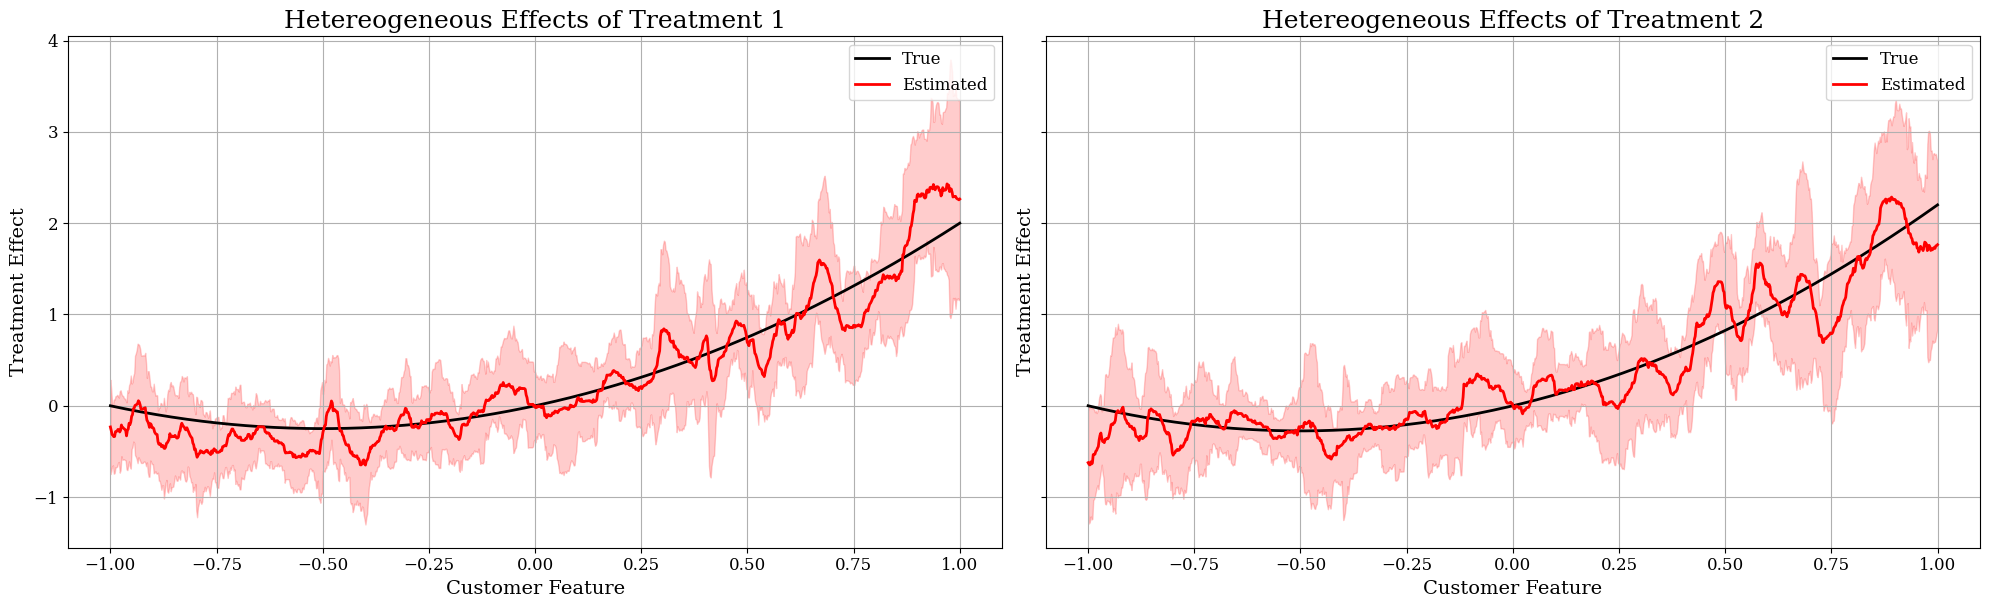

In [9]:
for max_depth in [2, 3, 4, 5, 6, 7, 8, 9, 10]:
    print(f"\nMax_depth = {max_depth}")
    cfdml = CausalForestDML(
        n_treatments=2, model_t=LogisticRegression(C=0.01), model_y=Lasso(alpha=0.01), 
        n_estimators=100, max_depth=max_depth, n_jobs=-1, discrete_treatment=True
    ).fit(X=cust_features, Y=outcomes, T=treatments)

    avg_var = np.mean(cfdml.predict_incremental_effect(oos_cust_features)[1])
    print(f"Average variance = {avg_var}")

    plot_hte(dgp, model=cfdml, ci=True)

# Selection

In [10]:
selection, val_est = optimize(cfdml, oos_cust_features)

# Evaluation

In [11]:
val_true = obj_func(
    selection=selection, 
    cust_feautres=oos_cust_features, 
    demand_model=dgp,
)

result_df = pd.DataFrame({
    'Policy Value': [val_est, val_true, val_est - val_true]
}, index=['Estimated', 'True', "Winner's Curse"])
result_df

,Policy Value
Estimated,1.121112
True,1.019002
Winner's Curse,0.102109


In [12]:
del dgp, cfdml, selection, val_est, val_true, result_df 
del cust_features, treatments, outcomes, oos_cust_features

# Winner's Curse

In [64]:
optimization_params = {
    'rank_and_select': {
        'optimizer': optimize, 'params': {}, 'display_name': 'Rank and Select'
    }
}

dgp_params = {
    'base_effect_vars': [PointMass(1 + i * 0.1) for i in range(2)], 
    'cust_feat_var': UnivariateGaussian(0, 1), 
    'char_func': lambda x: x**2 + x, 
    'noise_var': UnivariateGaussian(0, 1), 
    'response_type': 'continuous', 
    'dgp_seed': 0
}

data_params = {'sample_size': 1000, 'targ_sample_size': 100} 

experiment_params = {
    'n_repeats': 500, 
    'estimator': {
        'estimator': CausalForestDML, 
        'params': {
            'n_treatments': len(dgp_params['base_effect_vars']), 
            'model_t': LogisticRegression(C=0.01), 
            'model_y': Lasso(alpha=0.01), 
            'n_estimators': 100, 
            'max_depth': 30, 
            'n_jobs': -1, 
            'discrete_treatment': True
        }
    }
}

estimators_dict = {}

In [ ]:
result_records = repeated_experiment(
    optimization_params=optimization_params, 
    dgp_params=dgp_params, 
    data_params=data_params, 
    experiment_params=experiment_params, 
    estimators_dict=estimators_dict, 
    verbose=True, 
    n_jobs=-1
)

wc_measures_dict = calculate_winners_curse_measures(
    result_records=result_records, 
    optimization_params=optimization_params, 
    estimators_dict=estimators_dict, 
    data_params=data_params
)

Running 500 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.


In [ ]:
delta_tau = dgp_params['base_effect_vars'][1].mean - dgp_params['base_effect_vars'][0].mean

for optimizer in optimization_params.keys():
    display_name = optimization_params[optimizer]['display_name']

    # unpack results
    wc_arr = np.array([result[f'{optimizer}_wc'] for result in result_records])
    val_true_arr = np.array([result[f'{optimizer}_val_true'] for result in result_records])
    val_est_arr = np.array([result[f'{optimizer}_val_est'] for result in result_records])

    wc_avg = wc_arr.mean()
    wc_se = wc_arr.std() / data_params['sample_size'] ** 0.5 

    val_true_avg = val_true_arr.mean()
    val_true_se = val_true_arr.std() / data_params['sample_size'] ** 0.5
    val_est_avg = val_est_arr.mean()
    val_est_se = val_est_arr.std() / data_params['sample_size'] ** 0.5

    print(f'\nSelection with {display_name}:')
    print(f'  - Average True Value: {val_true_avg:.4f} ({val_true_se:.4f})')
    print(f'  - Average Estimated Value: {val_est_avg:.4f} ({val_est_se:.4f})')
    print(f'  - Average Winner\'s Curse (%): {wc_avg/delta_tau:.2%} ({wc_se/delta_tau:.2%})')


Selection with Rank and Select:
  - Average True Value: 1.0803 (0.0026)
  - Average Estimated Value: 1.2000 (0.0027)
  - Average Winner's Curse (%): 119.63% (0.57%)


# Estimating Winner's Curse

In [16]:
dgp = Targeting(**dgp_params)

cust_features, treatments, outcomes = dgp.sample(data_params['sample_size'], seed=484)
oos_cust_features = dgp.sample_individuals(data_params['sample_size'])

## Standard Bootstrap

In [9]:
boot_wc_dstn_dict = get_wc_boot_dstn(
    cust_features=cust_features, 
    treatments=treatments, 
    outcomes=outcomes, 
    targ_cust_features=oos_cust_features, 
    optimization_params=optimization_params, 
    estimator=experiment_params['estimator']['estimator'], 
    estimator_params=experiment_params['estimator']['params'], 
    n_bootstraps=500, 
    emp_targ_te_arr=None, 
    n_jobs=-1, 
    verbose=True, 
    seed=0
)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:    2.4s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:    6.5s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    8.2s finished


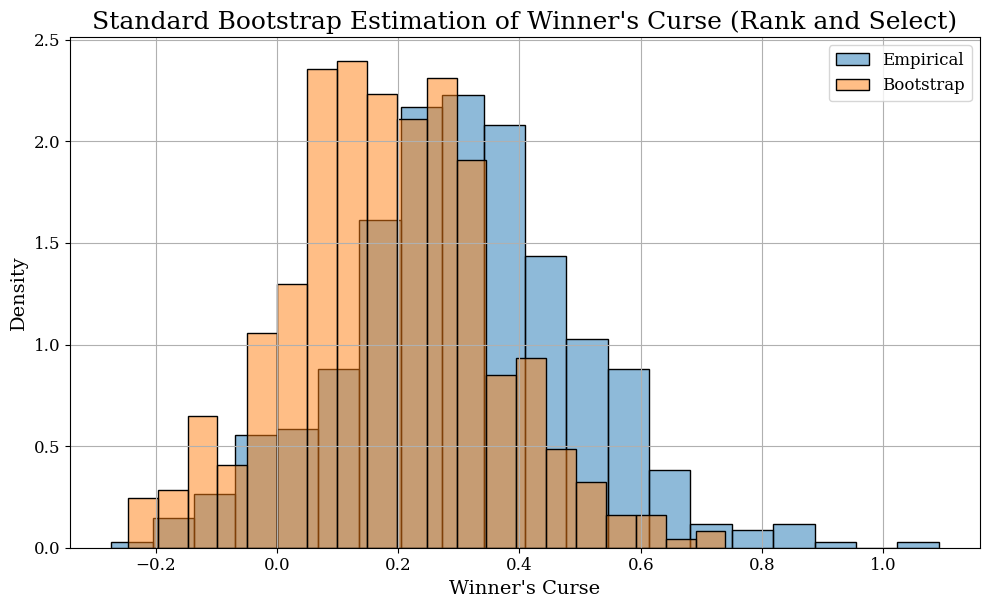

In [10]:
optimizer_name = 'rank_and_select'

fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

display_name = optimization_params[optimizer_name]['display_name']

wc_dstn = np.array([result[f'{optimizer_name}_wc'] for result in result_records])
wc_boot_dstn = boot_wc_dstn_dict[optimizer_name]

sns.histplot(wc_dstn, bins=20, color='C0', alpha=0.5, stat='density', label='Empirical', ax=ax)
sns.histplot(wc_boot_dstn, bins=20, color='C1', alpha=0.5, stat='density', label='Bootstrap', ax=ax)
ax.set_xlabel('Winner\'s Curse', fontsize=axis_label_size)
ax.set_ylabel('Density', fontsize=axis_label_size)
ax.set_title(f'Standard Bootstrap Estimation of Winner\'s Curse ({display_name})', fontsize=title_size)
ax.tick_params(axis='both', labelsize=tick_label_size)
ax.legend(fontsize=legend_label_size)
ax.grid()

plt.tight_layout()
plt.show()

## m-out-of-n Bootstrap

In [11]:
boot_wc_dstn_dict = get_wc_m_out_of_n_boot_dstn(
    cust_features=cust_features, 
    treatments=treatments, 
    outcomes=outcomes, 
    targ_cust_features=oos_cust_features, 
    optimization_params=optimization_params, 
    estimator=experiment_params['estimator']['estimator'], 
    estimator_params=experiment_params['estimator']['params'], 
    n_bootstraps=500, 
    emp_targ_te_arr=None, 
    power=0.95, 
    n_jobs=-1, 
    verbose=True, 
    seed=0
)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:    2.1s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:    6.1s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    7.6s finished


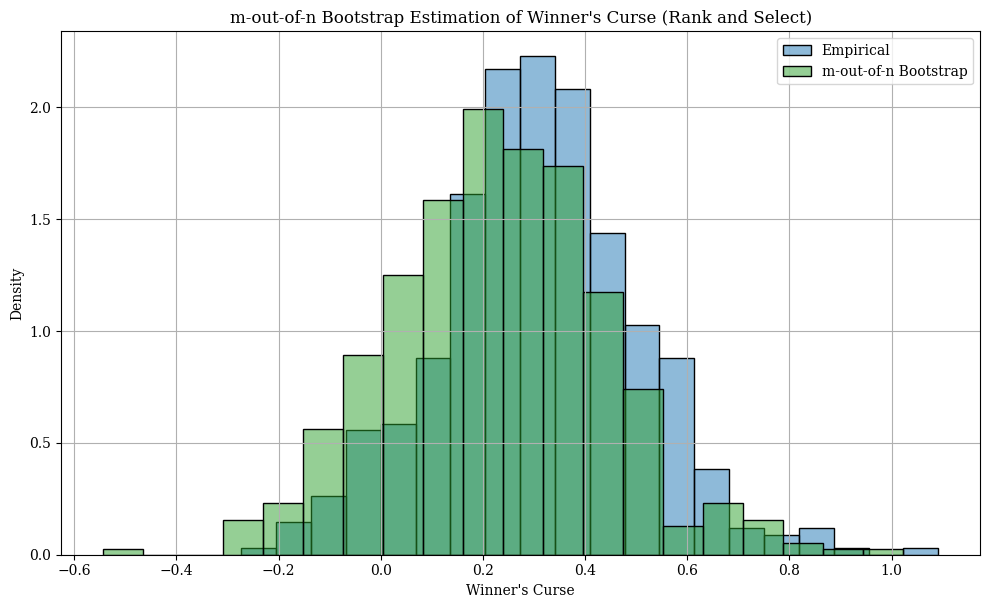

In [12]:
optimizer_name = 'rank_and_select'

fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

display_name = optimization_params[optimizer_name]['display_name']

wc_dstn = np.array([result[f'{optimizer_name}_wc'] for result in result_records])
wc_boot_dstn = boot_wc_dstn_dict[optimizer_name]

sns.histplot(wc_dstn, bins=20, color='C0', alpha=0.5, stat='density', label='Empirical', ax=ax)
sns.histplot(wc_boot_dstn, bins=20, color='C2', alpha=0.5, stat='density', label='m-out-of-n Bootstrap', ax=ax)
ax.set_xlabel('Winner\'s Curse')
ax.set_ylabel('Density')
ax.set_title(f'm-out-of-n Bootstrap Estimation of Winner\'s Curse ({display_name})')
ax.legend()
ax.grid()

plt.tight_layout()
plt.show()

## Numerical Bootstrap

In [13]:
boot_wc_dstn_dict = get_wc_num_boot_dstn(
    cust_features=cust_features, 
    treatments=treatments, 
    outcomes=outcomes, 
    targ_cust_features=oos_cust_features, 
    optimization_params=optimization_params, 
    estimator=experiment_params['estimator']['estimator'], 
    estimator_params=experiment_params['estimator']['params'], 
    n_bootstraps=500, 
    emp_targ_te_arr=None, 
    power=-0.45, 
    n_jobs=-1, 
    verbose=True, 
    seed=0
)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:    2.5s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:    6.5s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    8.2s finished


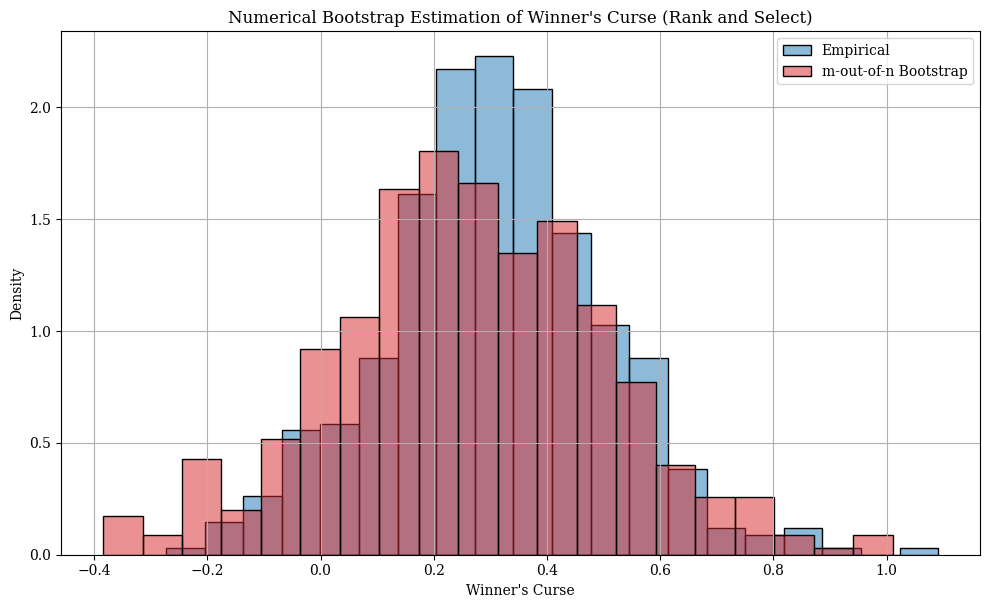

In [14]:
optimizer_name = 'rank_and_select'

fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

display_name = optimization_params[optimizer_name]['display_name']

wc_dstn = np.array([result[f'{optimizer_name}_wc'] for result in result_records])
wc_boot_dstn = boot_wc_dstn_dict[optimizer_name]

sns.histplot(wc_dstn, bins=20, color='C0', alpha=0.5, stat='density', label='Empirical', ax=ax)
sns.histplot(wc_boot_dstn, bins=20, color='C3', alpha=0.5, stat='density', label='m-out-of-n Bootstrap', ax=ax)
ax.set_xlabel('Winner\'s Curse')
ax.set_ylabel('Density')
ax.set_title(f'Numerical Bootstrap Estimation of Winner\'s Curse ({display_name})')
ax.legend()
ax.grid()

plt.tight_layout()
plt.show()

# Bias Correction

In [5]:
optimization_params = {
    'rank_and_select': {
        'optimizer': optimize, 'params': {}, 'display_name': 'Rank and Select'
    }
}

dgp_params = {
    'base_effect_vars': [PointMass(1), PointMass(1.1)], 
    'cust_feat_var': UnivariateGaussian(0, 1), 
    'char_func': lambda x: x**2 + x, 
    'noise_var': UnivariateGaussian(0, 1), 
    'response_type': 'continuous', 
    'dgp_seed': 0
}

data_params = {'sample_size': 100, 'targ_sample_size': 100} 

experiment_params = {
    'n_repeats': 500, 
    'estimator': {
        'estimator': CausalForestDML, 
        'params': {
            'n_treatments': len(dgp_params['base_effect_vars']), 
            'model_t': LogisticRegression(C=0.01), 
            'model_y': Lasso(alpha=0.01), 
            'n_estimators': 100, 
            'max_depth': 5, 
            'n_jobs': -1, 
            'discrete_treatment': True
        }
    }
}

estimators_dict = {
    'sample_splitting': {
        'estimator': sample_splitting_estimate, 
        'params': {'estimation_split': 0.5, }, 
        'display_name': 'Sample Splitting', 
    }, 
    'standard_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 100, 'n_jobs': -1}, 
        'display_name': 'Standard Bootstrap'
    },
    'mn_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'bootstrap_method': 'm_out_of_n', 'n_bootstraps': 100, 'power': 0.95, 'n_jobs': -1}, 
        'display_name': 'm-out-of-n Bootstrap'
    },
    'num_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'bootstrap_method': 'numerical', 'n_bootstraps': 100, 'power': -0.45, 'n_jobs': -1}, 
        'display_name': 'Numerical Bootstrap'
    }, 
    'bayes_normal': {
        'estimator': bayes_estimate, 
        'params': {'prior': 'normal', 'prior_mean': 0.0, 'prior_std': 1.0},
        'display_name': 'Shrinkage'
    }, 
    'eb_spike_slab': {
        'estimator': empirical_bayes_estimate, 
        'params': {'prior': 'spike_slab', 'pi': 0.5},
        'display_name': 'EB (Spike-and-Slab)'
    }, 
    'conditional_si': {
        'estimator': selective_inference_estimate,
        'params': {'method': 'conditional', 'quantile': 0.5, 'n_jobs': -1}, 
        'display_name': 'Conditional SI'
    }, 
    'hybrid_si': {
        'estimator': selective_inference_estimate,
        'params': {'method': 'hybrid', 'quantile': 0.5, 'n_jobs': -1}, 
        'display_name': 'Hybrid SI'
    }, 
}

In [ ]:
result_records = repeated_experiment(
    optimization_params=optimization_params, 
    dgp_params=dgp_params, 
    data_params=data_params, 
    experiment_params=experiment_params, 
    estimators_dict=estimators_dict, 
    verbose=True, 
    n_jobs=-1
)

wc_measures_dict = calculate_winners_curse_measures(
    result_records=result_records, 
    optimization_params=optimization_params, 
    estimators_dict=estimators_dict, 
    data_params=data_params
)

Running 500 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.


In [6]:
# with open('results/targeting_bias_correction_large_sample.pkl', 'wb') as f:
#     pickle.dump(wc_measures_dict, f)

with open('results/targeting_bias_correction_large_sample.pkl', 'rb') as f:
    wc_measures_dict = pickle.load(f)


Selection with Rank and Select:
Policy Value: 
  - True Value: 1.0655 (0.0187)
  - No Correction: 1.1962 (0.0230)
  - Standard Bootstrap: 1.0964 (0.0250)
  - m-out-of-n Bootstrap: 1.0679 (0.0253)
  - Numerical Bootstrap: 1.0644 (0.0260)
  - Shrinkage: 0.8686 (0.0178)
  - EB (Spike-and-Slab): 1.0746 (0.0216)
  - Conditional SI: -0.0422 (0.1055)
  - Hybrid SI: 0.7863 (0.0282)

Winner's Curse: 
Average Winner's Curse: 
  - No Correction: 130.72% (19.89%)
  - Standard Bootstrap: 30.87% (22.65%)
  - m-out-of-n Bootstrap: 2.42% (22.37%)
  - Numerical Bootstrap: -1.10% (23.90%)
  - Shrinkage: -196.94% (19.53%)
  - EB (Spike-and-Slab): 9.13% (18.83%)
  - Conditional SI: -1106.05% (104.41%)
  - Hybrid SI: -279.16% (26.76%)
Median Winner's Curse: 
  - No Correction: 124.98% (19.89%)
  - Standard Bootstrap: 25.23% (22.65%)
  - m-out-of-n Bootstrap: 4.38% (22.37%)
  - Numerical Bootstrap: -11.61% (23.90%)
  - Shrinkage: -183.26% (19.53%)
  - EB (Spike-and-Slab): 6.60% (18.83%)
  - Conditional SI:

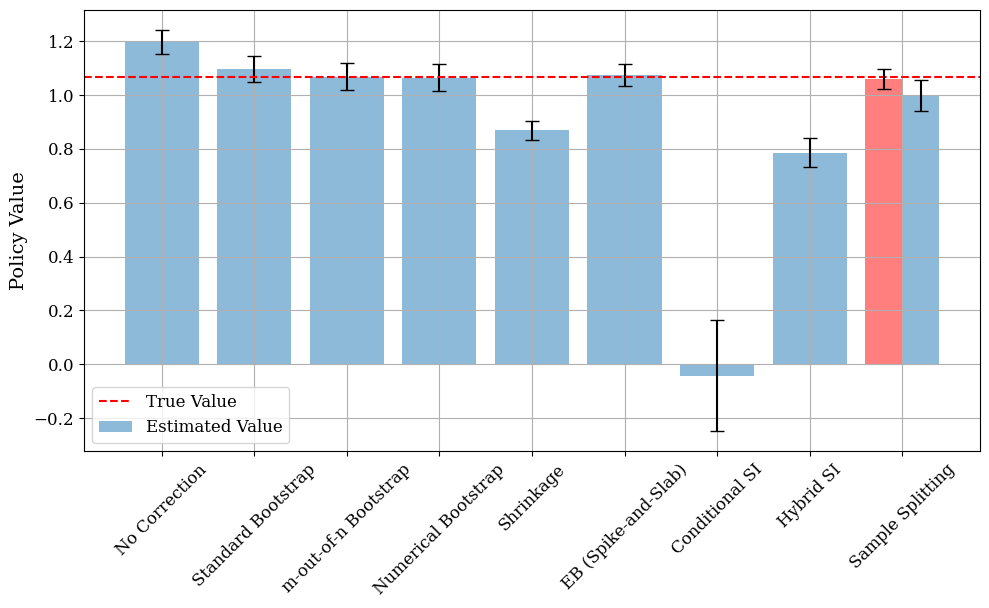

In [7]:
delta_tau = dgp_params['base_effect_vars'][1].mean - dgp_params['base_effect_vars'][0].mean

optimizer_key = 'rank_and_select'

print(f'\nSelection with {optimization_params[optimizer_key]["display_name"]}:')

val_true_avg = wc_measures_dict[f'{optimizer_key}_nc_val_true_avg']
val_true_se = wc_measures_dict[f'{optimizer_key}_nc_val_true_se']

print(f'Policy Value: ')
print(f'  - True Value: {val_true_avg:.4f} ({val_true_se:.4f})')
for estimator_name in ['nc'] + [k for k in estimators_dict.keys() if k != 'sample_splitting']:
    if estimator_name == 'sample_splitting':
        continue
    est_avg = wc_measures_dict[f'{optimizer_key}_{estimator_name}_val_est_avg']
    est_se = wc_measures_dict[f'{optimizer_key}_{estimator_name}_val_est_se']
    display_name = estimators_dict[estimator_name]['display_name'] if estimator_name != 'nc' else 'No Correction'

    print(f'  - {display_name}: {est_avg:.4f} ({est_se:.4f})')

print(f'\nWinner\'s Curse: ')
print(f"Average Winner's Curse: ")
for estimator_name in ['nc'] + [k for k in estimators_dict.keys() if k != 'sample_splitting']:
    if estimator_name == 'sample_splitting':
        continue
    wc_avg = wc_measures_dict[f'{optimizer_key}_{estimator_name}_wc_avg']
    wc_se = wc_measures_dict[f'{optimizer_key}_{estimator_name}_wc_se']
    display_name = estimators_dict[estimator_name]['display_name'] if estimator_name != 'nc' else 'No Correction'

    print(f'  - {display_name}: {wc_avg/delta_tau:.2%} ({wc_se/delta_tau:.2%})')

print(f'Median Winner\'s Curse: ')
for estimator_name in ['nc'] + [k for k in estimators_dict.keys() if k != 'sample_splitting']:
    if estimator_name == 'sample_splitting':
        continue
    wc_median = np.nanmedian(wc_measures_dict[f'{optimizer_key}_{estimator_name}_wc_arr'])
    wc_se = wc_measures_dict[f'{optimizer_key}_{estimator_name}_wc_se']
    display_name = estimators_dict[estimator_name]['display_name'] if estimator_name != 'nc' else 'No Correction'

    print(f'  - {display_name}: {wc_median/delta_tau:.2%} ({wc_se/delta_tau:.2%})')

if 'sample_splitting' in estimators_dict.keys():
    print(f'\nSample Splitting: ')
    ss_val_true_avg = wc_measures_dict[f'{optimizer_key}_sample_splitting_val_true_avg']
    ss_val_true_se = wc_measures_dict[f'{optimizer_key}_sample_splitting_val_true_se']
    ss_val_est_avg = wc_measures_dict[f'{optimizer_key}_sample_splitting_val_est_avg']
    ss_val_est_se = wc_measures_dict[f'{optimizer_key}_sample_splitting_val_est_se']
    ss_wc_avg = wc_measures_dict[f'{optimizer_key}_sample_splitting_wc_avg']
    ss_wc_se = wc_measures_dict[f'{optimizer_key}_sample_splitting_wc_se']

    print(f'  - True Value: {ss_val_true_avg:.4f} ({ss_val_true_se:.4f})')
    print(f'  - Estimated Value: {ss_val_est_avg:.4f} ({ss_val_est_se:.4f})')
    print(f'  - Winner\'s Curse (%): {ss_wc_avg/delta_tau:.2%} ({ss_wc_se/delta_tau:.2%})')

# bar plot comparing the true value and estiamted value frome each estimator 
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

bar_positions = np.arange(len(estimators_dict.keys()) + 1 - int('sample_splitting' in estimators_dict.keys()))
bar_values = [
    wc_measures_dict[f'{optimizer_key}_{estimator_name}_val_est_avg']
    for estimator_name in ['nc'] + [k for k in estimators_dict.keys() if k != 'sample_splitting']
]
bar_errors = [
    1.96 * wc_measures_dict[f'{optimizer_key}_{estimator_name}_val_est_se']
    for estimator_name in ['nc'] + [k for k in estimators_dict.keys() if k != 'sample_splitting']
]

# plot the bars
ax.bar(bar_positions, bar_values, yerr=bar_errors, capsize=5, color='C0', alpha=0.5, label='Estimated Value')
ax.axhline(y=val_true_avg, color='red', linestyle='--', label='True Value')

# plot the bar for sample splitting if it exists
if 'sample_splitting' in estimators_dict.keys():
    # two side-by-side bars for sample splitting, one for true value and one for estimated value
    bar_width = 0.4
    ax.bar(bar_positions[-1] + 1 - bar_width / 2, ss_val_true_avg, yerr=1.95 * ss_val_true_se, capsize=5, color='red', width=bar_width, alpha=0.5)
    ax.bar(bar_positions[-1] + 1 + bar_width / 2, ss_val_est_avg, yerr=1.95 * ss_val_est_se, capsize=5, color='C0', width=bar_width, alpha=0.5)

# ax.set_xlabel('Estimator')
ax.set_ylabel('Policy Value', fontsize=axis_label_size)
# ax.set_title(f'{optimization_params[optimizer_key]["display_name"]} Selection', fontsize=title_size)
if 'sample_splitting' in estimators_dict.keys():
    ax.set_xticks(
        np.arange(len(estimators_dict) + 1), 
        labels=['No Correction'] + [v['display_name'] for k, v in estimators_dict.items() if k != 'sample_splitting'] + ['Sample Splitting'], 
        rotation=45, 
        fontsize=tick_label_size
    )
else:
    ax.set_xticks(
        np.arange(len(estimators_dict) + 1), 
        labels=['No Correction'] + [v['display_name'] for k, v in estimators_dict.items()], 
        rotation=45, 
        fontsize=tick_label_size
    )
# ax.set_ylim([0.9, 1.2])
ax.tick_params(axis='both', labelsize=tick_label_size)
ax.legend(fontsize=legend_label_size)
ax.grid()
plt.tight_layout()
plt.show()


In [16]:
np.mean(wc_measures_dict['rank_and_select_hybrid_si_val_est_arr']), np.median(wc_measures_dict['rank_and_select_hybrid_si_val_est_arr'])

(0.7863395139633133, 0.7732520125018907)

# Comparative Statics

## Delta Tau

In [ ]:
optimization_params = {
    'rank_and_select': {
        'optimizer': optimize, 'params': {}, 'display_name': 'Rank and Select'
    }
}

dgp_params = {
    'base_effect_vars': [None, None], 
    'cust_feat_var': UnivariateGaussian(0, 1), 
    'char_func': lambda x: x**2 + x, 
    'noise_var': UnivariateGaussian(0, 1), 
    'response_type': 'continuous', 
    'dgp_seed': 0
}

data_params = {'sample_size': 100, 'targ_sample_size': 100} 

experiment_params = {
    'n_repeats': 500, 
    'estimator': {
        'estimator': CausalForestDML, 
        'params': {
            'n_treatments': len(dgp_params['base_effect_vars']), 
            'model_t': LogisticRegression(C=0.01), 
            'model_y': Lasso(alpha=0.01), 
            'n_estimators': 100, 
            'max_depth': 5, 
            'n_jobs': -1, 
            'discrete_treatment': True
        }
    }
}

estimators_dict = {
    'sample_splitting': {
        'estimator': sample_splitting_estimate, 
        'params': {'estimation_split': 0.5, }, 
        'display_name': 'Sample Splitting', 
    }, 
    'standard_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 100, 'n_jobs': -1}, 
        'display_name': 'Standard Bootstrap'
    },
    'mn_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'bootstrap_method': 'm_out_of_n', 'n_bootstraps': 100, 'power': 0.95, 'n_jobs': -1}, 
        'display_name': 'm-out-of-n Bootstrap'
    },
    'num_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'bootstrap_method': 'numerical', 'n_bootstraps': 100, 'power': -0.45, 'n_jobs': -1}, 
        'display_name': 'Numerical Bootstrap'
    }, 
    'bayes_normal': {
        'estimator': bayes_estimate, 
        'params': {'prior': 'normal', 'prior_mean': 0.0, 'prior_std': 1.0},
        'display_name': 'Shrinkage'
    }, 
    # 'eb_spike_slab': {
    #     'estimator': empirical_bayes_estimate, 
    #     'params': {'prior': 'spike_slab', 'pi': 0.5},
    #     'display_name': 'EB (Spike-and-Slab)'
    # }, 
    'conditional_si': {
        'estimator': selective_inference_estimate,
        'params': {'method': 'conditional', 'quantile': 0.5, 'n_jobs': -1}, 
        'display_name': 'Conditional SI'
    }, 
    # 'hybrid_si': {
    #     'estimator': selective_inference_estimate,
    #     'params': {'method': 'hybrid', 'quantile': 0.5, 'n_jobs': -1}, 
    #     'display_name': 'Hybrid SI'
    # }, 
}

tau_list = [
    (1, 1.01),(1, 1.05), (1, 1.1), (2, 2.1), (3, 3.1), (1, 1.5)
]

In [ ]:
tau_result_dict = {tau: None for tau in tau_list}

for te_tuple in tau_list:
    print(f'\n(tau_1, tau_2)= {te_tuple}')
    
    dgp_params['base_effect_vars'] = [PointMass(te_tuple[0]), PointMass(te_tuple[1])]

    result_records = repeated_experiment(
        optimization_params=optimization_params, 
        dgp_params=dgp_params, 
        data_params=data_params, 
        experiment_params=experiment_params, 
        estimators_dict=estimators_dict, 
        verbose=True, 
        n_jobs=-1
    )

    tau_result_dict[te_tuple] = calculate_winners_curse_measures(
        result_records=result_records, 
        optimization_params=optimization_params, 
        estimators_dict=estimators_dict, 
        data_params=data_params
    )

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



(tau_1, tau_2)= (1, 1.01)
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:  7.6min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed: 20.2min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed: 25.8min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



(tau_1, tau_2)= (1, 1.05)
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:  7.6min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed: 20.7min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed: 26.1min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.


...

[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:  7.7min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed: 20.8min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed: 26.3min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



(tau_1, tau_2)= (3, 3.1)
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:  7.8min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed: 20.8min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed: 26.7min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



(tau_1, tau_2)= (1, 1.5)
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:  7.7min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed: 21.0min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed: 26.7min finished


In [29]:
# with open('results/targeting_delta_tau.pkl', 'wb') as f:
#     pickle.dump(tau_result_dict, f)

with open('results/targeting_delta_tau.pkl', 'rb') as f:
    tau_result_dict = pickle.load(f)

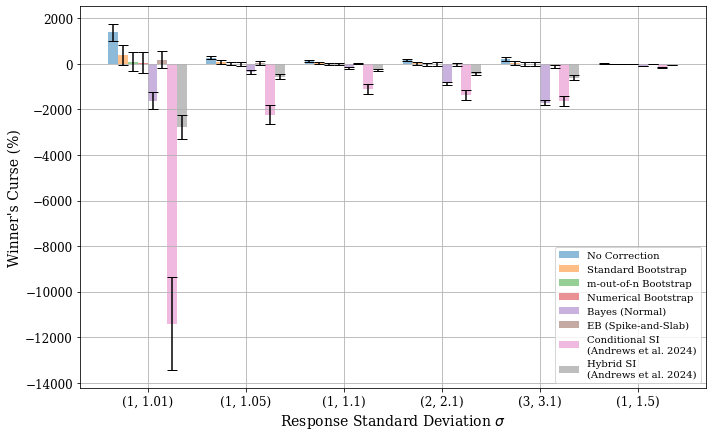

$\Delta\tau = 0.01$  \
                                             $(\tau_1, \tau_2)$ = (1, 1.01)   
No Correction                         Mean                          1381.80   
                                      Median                        1372.81   
                                      S.E.                           192.71   
Standard Bootstrap                    Mean                           375.06   
                                      Median                         337.76   
                                      S.E.                           220.63   
m-out-of-n Bootstrap                  Mean                            94.07   
                                      Median                          33.43   
                                      S.E.                           217.31   
Numerical Bootstrap                   Mean                            44.15   
                                      Median                         -54.85   
                                      S.E.                           233.32   
Bayes (Normal)                        Mean                         -1614.27   
                                      Median                       -1529.25   
                                      S.E.                           186.46   
EB (Spike-and-Slab)                   Mean                           188.15   
                                      Median                         209.21   
                                      S.E.                           182.72   
Conditional SI\n(Andrews et al. 2024) Mean                        -11413.88   
                                      Median                       -8216.10   
                                      S.E.                          1042.60   
Hybrid SI\n(Andrews et al. 2024)      Mean                         -2788.22   
                                      Median                       -2651.33   
                                      S.E.                           267.33   

                                                        $\Delta\tau = 0.05$  \
                                             $(\tau_1, \tau_2)$ = (1, 1.05)   
No Correction                         Mean                           272.44   
                                      Median                         267.71   
                                      S.E.                            38.97   
Standard Bootstrap                    Mean                            72.52   
                                      Median                          52.58   
                                      S.E.                            44.60   
m-out-of-n Bootstrap                  Mean                            14.52   
                                      Median                           3.89   
                                      S.E.                            43.87   
Numerical Bootstrap                   Mean                             5.46   
                                      Median                          -5.41   
                                      S.E.                            46.92   
Bayes (Normal)                        Mean                          -351.48   
                                      Median                        -330.50   
                                      S.E.                            37.98   
EB (Spike-and-Slab)                   Mean                            31.21   
                                      Median                          27.68   
                                      S.E.                            37.06   
Conditional SI\n(Andrews et al. 2024) Mean                         -2224.64   
                                      Median                       -1566.04   
                                      S.E.                           208.12   
Hybrid SI\n(Andrews et al. 2024)      Mean                          -562.19   
                                      Median                        -553.23   
                          

In [30]:
# parameters
optimizer_key = 'rank_and_select'
result_dict = tau_result_dict.copy()

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys() if est_key != 'sample_splitting'
]

# For each delta tau value
for key in result_dict.keys():
    delta_tau = key[1] - key[0]

    data[key] = {}

    data[key]['No Correction'] = {
        'Mean': 100 / delta_tau * result_dict[key][f'{optimizer_key}_nc_wc_avg'],
        'Median': 100 / delta_tau * np.nanmedian(result_dict[key][f'{optimizer_key}_nc_wc_arr']),
        'S.E.': 100 / delta_tau * result_dict[key][f'{optimizer_key}_nc_wc_se']
    }
    
    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys() if k != 'sample_splitting']):
        est_name = estimator_names[i+1]
        
        # Extract values
        mean_wc = 100 / delta_tau * result_dict[key][f'{optimizer_key}_{est_key}_wc_avg']
        median_wc = 100 / delta_tau * np.nanmedian(result_dict[key][f'{optimizer_key}_{est_key}_wc_arr'])
        se_wc = 100 / delta_tau * result_dict[key][f'{optimizer_key}_{est_key}_wc_se']
        
        # Store in nested dictionary
        data[key][est_name] = {
            'Mean': mean_wc, 'Median': median_wc, 'S.E.': se_wc
        }

# Create the MultiIndex DataFrame
row_index = pd.MultiIndex.from_product([
    estimator_names, ['Mean', 'Median', 'S.E.']
])
col_index = pd.MultiIndex.from_tuples([
    (f'$\Delta\tau = {np.round(key[1] - key[0], 2)}$', '$(\tau_1, \tau_2)$ = ({}, {})'.format(key[0], key[1]))
    for key in result_dict.keys()
])

# Prepare data for DataFrame
df_data = []
for key in result_dict.keys():
    column_data = []
    for est_name in estimator_names:
        for stat in ['Mean', 'Median', 'S.E.']:
            column_data.append(data[key][est_name][stat])
    df_data.append(column_data)

# Create DataFrame with two-level column MultiIndex: Ratio and parameter info
wc_stats_df = pd.DataFrame(
    np.array(df_data).T,
    index=row_index,
    columns=col_index, 
)


""" 
Visualize the Winner's Curse
"""
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

n_estimators = len(estimators_dict.keys())
bar_positions = np.arange(len(tau_list))
bar_width = 0.1 * n_estimators

# plot the bars
for idx, estimator in enumerate(estimator_names):
    
    bar_values = [data[p][estimator]['Mean'] for p in tau_list]
    bar_errors = [1.96 * data[p][estimator]['S.E.'] for p in tau_list]

    ax.bar(
        bar_positions - bar_width / 2 + idx * bar_width / n_estimators + bar_width / 2 / n_estimators,
        bar_values, yerr=bar_errors, capsize=5,
        label=estimator, alpha=0.5, width=bar_width / n_estimators
    )

ax.set_xlabel(r'Response Standard Deviation $\sigma$', fontsize=axis_label_size)
ax.set_ylabel('Winner\'s Curse (%)', fontsize=axis_label_size)
ax.set_xticks(
    np.arange(len(tau_list)), labels=tau_list, 
)
ax.tick_params(axis='both', labelsize=tick_label_size)
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()

# delete all variables in this cell
del data, estimator_names, df_data, idx, bar_positions, bar_width, bar_values, bar_errors, optimizer_key
del result_dict

# Display the DataFrame
wc_stats_df.round(2)

In [37]:
print(wc_stats_df[[f'$\Delta\tau = {delta_tau}$' for delta_tau in [0.05, 0.1, 0.5]]].map(lambda x: f'{x:.2f}\%').style.to_latex())

\begin{tabular}{lllllll}
 &  & $\Delta	au = 0.05$ & \multicolumn{3}{r}{$\Delta	au = 0.1$} & $\Delta	au = 0.5$ \\
 &  & $(	au_1, 	au_2)$ = (1, 1.05) & $(	au_1, 	au_2)$ = (1, 1.1) & $(	au_1, 	au_2)$ = (2, 2.1) & $(	au_1, 	au_2)$ = (3, 3.1) & $(	au_1, 	au_2)$ = (1, 1.5) \\
\multirow[c]{3}{*}{No Correction} & Mean & 272.44\% & 130.72\% & 169.08\% & 206.01\% & 11.18\% \\
 & Median & 267.71\% & 124.98\% & 178.93\% & 205.57\% & 10.04\% \\
 & S.E. & 38.97\% & 19.89\% & 28.66\% & 38.26\% & 4.65\% \\
\multirow[c]{3}{*}{Standard Bootstrap} & Mean & 72.52\% & 31.00\% & 36.87\% & 55.40\% & -1.48\% \\
 & Median & 52.58\% & 24.72\% & 20.33\% & 16.38\% & -4.12\% \\
 & S.E. & 44.60\% & 22.61\% & 33.20\% & 45.24\% & 5.30\% \\
\multirow[c]{3}{*}{m-out-of-n Bootstrap} & Mean & 14.52\% & 3.33\% & -11.02\% & -22.98\% & -6.78\% \\
 & Median & 3.89\% & 2.61\% & -24.77\% & -49.56\% & -11.19\% \\
 & S.E. & 43.87\% & 22.43\% & 32.25\% & 43.59\% & 5.21\% \\
\multirow[c]{3}{*}{Numerical Bootstrap} & Mean & 5.46\% 

## Sample Size

In [41]:
optimization_params = {
    'rank_and_select': {
        'optimizer': optimize, 'params': {}, 'display_name': 'Rank and Select'
    }
}

dgp_params = {
    'base_effect_vars': [PointMass(1), PointMass(1.1)], 
    'cust_feat_var': UnivariateGaussian(0, 1), 
    'char_func': lambda x: x**2 + x, 
    'noise_var': UnivariateGaussian(0, 1), 
    'response_type': 'continuous', 
    'dgp_seed': 0
}

data_params = {'sample_size': None, 'targ_sample_size': 100} 

experiment_params = {
    'n_repeats': 500, 
    'estimator': {
        'estimator': CausalForestDML, 
        'params': {
            'n_treatments': len(dgp_params['base_effect_vars']), 
            'model_t': LogisticRegression(C=0.01), 
            'model_y': Lasso(alpha=0.01), 
            'n_estimators': 100, 
            'max_depth': 5, 
            'n_jobs': -1, 
            'discrete_treatment': True
        }
    }
}

estimators_dict = {
    'sample_splitting': {
        'estimator': sample_splitting_estimate, 
        'params': {'estimation_split': 0.5, }, 
        'display_name': 'Sample Splitting', 
    }, 
    'standard_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 100, 'n_jobs': -1}, 
        'display_name': 'Standard Bootstrap'
    },
    'mn_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'bootstrap_method': 'm_out_of_n', 'n_bootstraps': 100, 'power': 0.95, 'n_jobs': -1}, 
        'display_name': 'm-out-of-n Bootstrap'
    },
    'num_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'bootstrap_method': 'numerical', 'n_bootstraps': 100, 'power': -0.45, 'n_jobs': -1}, 
        'display_name': 'Numerical Bootstrap'
    }, 
    'bayes_normal': {
        'estimator': bayes_estimate, 
        'params': {'prior': 'normal', 'prior_mean': 0.0, 'prior_std': 1.0},
        'display_name': 'Shrinkage'
    }, 
    # 'eb_spike_slab': {
    #     'estimator': empirical_bayes_estimate, 
    #     'params': {'prior': 'spike_slab', 'pi': 0.5},
    #     'display_name': 'EB (Spike-and-Slab)'
    # }, 
    'conditional_si': {
        'estimator': selective_inference_estimate,
        'params': {'method': 'conditional', 'quantile': 0.5, 'n_jobs': -1}, 
        'display_name': 'Conditional SI'
    }, 
    # 'hybrid_si': {
    #     'estimator': selective_inference_estimate,
    #     'params': {'method': 'hybrid', 'quantile': 0.5, 'n_jobs': -1}, 
    #     'display_name': 'Hybrid SI'
    # }, 
}

sample_size_list = [100, 500, 1000, 2500, 5000]

In [ ]:
sample_size_result_dict = {sample_size: None for sample_size in sample_size_list}

for sample_size in sample_size_list:
    print(f'\nSample Size= {sample_size}')

    data_params['sample_size'] = sample_size    

    result_records = repeated_experiment(
        optimization_params=optimization_params, 
        dgp_params=dgp_params, 
        data_params=data_params, 
        experiment_params=experiment_params, 
        estimators_dict=estimators_dict, 
        verbose=True, 
        n_jobs=-1
    )

    sample_size_result_dict[sample_size] = calculate_winners_curse_measures(
        result_records=result_records, 
        optimization_params=optimization_params, 
        estimators_dict=estimators_dict, 
        data_params=data_params
    )


Sample Size= 100
Running 500 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:  7.8min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed: 20.9min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed: 26.7min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Sample Size= 500
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed: 11.7min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed: 31.4min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed: 39.9min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Sample Size= 1000
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed: 14.7min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed: 41.1min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed: 52.4min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Sample Size= 2500
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed: 24.1min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed: 68.2min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed: 86.0min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Sample Size= 5000
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed: 44.7min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed: 116.4min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed: 149.4min finished


In [42]:
# with open('results/targeting_sample_size.pkl', 'wb') as f:
#     pickle.dump(sample_size_result_dict, f)

with open('results/targeting_sample_size.pkl', 'rb') as f:
    sample_size_result_dict = pickle.load(f)

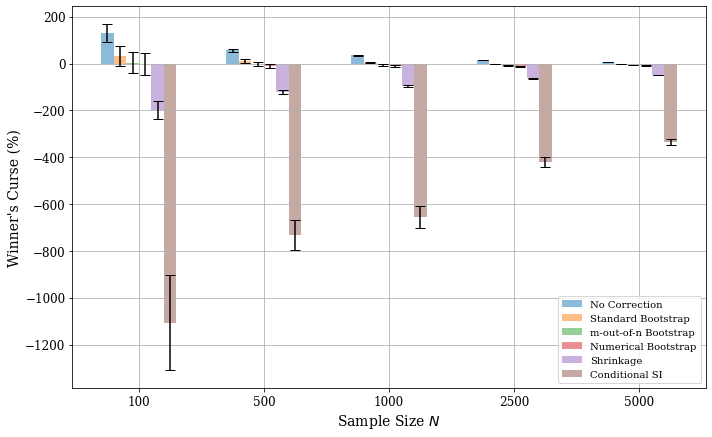

$N=100$  $N=500$  $N=1000$  $N=2500$  $N=5000$
No Correction        Mean     130.72    56.68     34.41     15.13      7.53
                     Median   124.98    58.06     34.35     17.02      8.46
                     S.E.      19.89     3.47      1.75      0.75      0.42
Standard Bootstrap   Mean      32.43    11.25      3.92     -2.07     -2.24
                     Median    30.42     9.62      5.59     -0.36     -1.98
                     S.E.      22.63     3.87      1.95      0.83      0.46
m-out-of-n Bootstrap Mean       4.18    -2.12     -6.96     -9.75     -7.02
                     Median     8.94    -3.76     -6.29     -7.72     -6.20
                     S.E.      22.44     3.89      1.93      0.84      0.46
Numerical Bootstrap  Mean      -1.09    -9.36    -11.18    -12.25     -8.18
                     Median   -10.62    -7.95     -9.63     -9.60     -7.59
                     S.E.      23.84     4.07      2.09      0.89      0.49
Shrinkage            Mean    -196.94  -122.56    -94.59    -63.96    -48.38
                     Median  -183.26  -108.82    -84.08    -56.20    -39.98
                     S.E.      19.53     4.61      2.54      1.04      0.68
Conditional SI       Mean   -1106.05  -731.86   -656.09   -420.86   -334.72
                     Median  -805.94  -525.60   -408.67   -238.11   -189.05
                     S.E.     104.41    32.45     23.64     11.18      6.88

In [43]:
# parameters
optimizer_key = 'rank_and_select'
result_dict = sample_size_result_dict.copy()
delta_tau = dgp_params['base_effect_vars'][1].mean - dgp_params['base_effect_vars'][0].mean

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys() if est_key != 'sample_splitting'
]

# For each delta tau value
for sample_size in sample_size_list:
    data[sample_size] = {}

    data[sample_size]['No Correction'] = {
        'Mean': 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_nc_wc_avg'],
        'Median': 100 / delta_tau * np.nanmedian(result_dict[sample_size][f'{optimizer_key}_nc_wc_arr']),
        'S.E.': 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_nc_wc_se']
    }
    
    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys() if k != 'sample_splitting']):
        est_name = estimator_names[i+1]
        
        # Extract values
        mean_wc = 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_{est_key}_wc_avg']
        median_wc = 100 / delta_tau * np.nanmedian(result_dict[sample_size][f'{optimizer_key}_{est_key}_wc_arr'])
        se_wc = 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_{est_key}_wc_se']
        
        # Store in nested dictionary
        data[sample_size][est_name] = {
            'Mean': mean_wc, 'Median': median_wc, 'S.E.': se_wc
        }

# Create the MultiIndex DataFrame
index = pd.MultiIndex.from_product([
    estimator_names, ['Mean', 'Median', 'S.E.']
])

# Prepare data for DataFrame
df_data = []
for sample_size in sample_size_list:
    column_data = []
    for est_name in estimator_names:
        for stat in ['Mean', 'Median', 'S.E.']:
            column_data.append(data[sample_size][est_name][stat])
    df_data.append(column_data)

# Create DataFrame
wc_stats_df = pd.DataFrame(
    np.array(df_data).T,
    index=index,
    columns=[r'$N={}$'.format(s_) for s_ in sample_size_list]
)


""" 
Visualize the Winner's Curse as a function of the treatment effect difference
"""

# plot the winner's curse as a function of the number of experiments
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

n_estimators = len(estimators_dict.keys())
bar_positions = np.arange(len(sample_size_list))
bar_width = 0.1 * n_estimators


# plot the bars
for idx, estimator in enumerate(estimator_names):
    
    bar_values = [data[s_][estimator]['Mean'] for s_ in sample_size_list]
    bar_errors = [1.96 * data[s_][estimator]['S.E.'] for s_ in sample_size_list]

    ax.bar(
        bar_positions - bar_width / 2 + idx * bar_width / n_estimators + bar_width / 2 / n_estimators,
        bar_values, yerr=bar_errors, capsize=5,
        label=estimator, alpha=0.5, width=bar_width / n_estimators
    )

ax.set_xlabel(r'Sample Size $N$', fontsize=axis_label_size)
ax.set_ylabel('Winner\'s Curse (%)', fontsize=axis_label_size)
ax.set_xticks(
    np.arange(len(sample_size_list)), labels=sample_size_list, 
)
ax.tick_params(axis='both', labelsize=tick_label_size)
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()

# delete all variables in this cell
del data, estimator_names, df_data, estimator, idx, bar_positions, bar_width, bar_values, bar_errors, n_estimators, optimizer_key
del result_dict

# Display the DataFrame
wc_stats_df.round(2)

In [44]:
print(wc_stats_df.map(lambda x: f'{x:.2f}\%').style.to_latex())

\begin{tabular}{lllllll}
 &  & $N=100$ & $N=500$ & $N=1000$ & $N=2500$ & $N=5000$ \\
\multirow[c]{3}{*}{No Correction} & Mean & 130.72\% & 56.68\% & 34.41\% & 15.13\% & 7.53\% \\
 & Median & 124.98\% & 58.06\% & 34.35\% & 17.02\% & 8.46\% \\
 & S.E. & 19.89\% & 3.47\% & 1.75\% & 0.75\% & 0.42\% \\
\multirow[c]{3}{*}{Standard Bootstrap} & Mean & 32.43\% & 11.25\% & 3.92\% & -2.07\% & -2.24\% \\
 & Median & 30.42\% & 9.62\% & 5.59\% & -0.36\% & -1.98\% \\
 & S.E. & 22.63\% & 3.87\% & 1.95\% & 0.83\% & 0.46\% \\
\multirow[c]{3}{*}{m-out-of-n Bootstrap} & Mean & 4.18\% & -2.12\% & -6.96\% & -9.75\% & -7.02\% \\
 & Median & 8.94\% & -3.76\% & -6.29\% & -7.72\% & -6.20\% \\
 & S.E. & 22.44\% & 3.89\% & 1.93\% & 0.84\% & 0.46\% \\
\multirow[c]{3}{*}{Numerical Bootstrap} & Mean & -1.09\% & -9.36\% & -11.18\% & -12.25\% & -8.18\% \\
 & Median & -10.62\% & -7.95\% & -9.63\% & -9.60\% & -7.59\% \\
 & S.E. & 23.84\% & 4.07\% & 2.09\% & 0.89\% & 0.49\% \\
\multirow[c]{3}{*}{Shrinkage} & Mean & -196

## Response STD

In [45]:
optimization_params = {
    'rank_and_select': {
        'optimizer': optimize, 'params': {}, 'display_name': 'Rank and Select'
    }
}

dgp_params = {
    'base_effect_vars': [PointMass(1), PointMass(1.1)], 
    'cust_feat_var': UnivariateGaussian(0, 1), 
    'char_func': lambda x: x**2 + x, 
    'noise_var': None, 
    'response_type': 'continuous', 
    'dgp_seed': 0
}

data_params = {'sample_size': 100, 'targ_sample_size': 100} 

experiment_params = {
    'n_repeats': 500, 
    'estimator': {
        'estimator': CausalForestDML, 
        'params': {
            'n_treatments': len(dgp_params['base_effect_vars']), 
            'model_t': LogisticRegression(C=0.01), 
            'model_y': Lasso(alpha=0.01), 
            'n_estimators': 100, 
            'max_depth': 5, 
            'n_jobs': -1, 
            'discrete_treatment': True
        }
    }
}

estimators_dict = {
    'sample_splitting': {
        'estimator': sample_splitting_estimate, 
        'params': {'estimation_split': 0.5, }, 
        'display_name': 'Sample Splitting', 
    }, 
    'standard_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 100, 'n_jobs': -1}, 
        'display_name': 'Standard Bootstrap'
    },
    'mn_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'bootstrap_method': 'm_out_of_n', 'n_bootstraps': 100, 'power': 0.95, 'n_jobs': -1}, 
        'display_name': 'm-out-of-n Bootstrap'
    },
    'num_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'bootstrap_method': 'numerical', 'n_bootstraps': 100, 'power': -0.45, 'n_jobs': -1}, 
        'display_name': 'Numerical Bootstrap'
    }, 
    'bayes_normal': {
        'estimator': bayes_estimate, 
        'params': {'prior': 'normal', 'prior_mean': 0.0, 'prior_std': 1.0},
        'display_name': 'Shrinkage'
    }, 
    # 'eb_spike_slab': {
    #     'estimator': empirical_bayes_estimate, 
    #     'params': {'prior': 'spike_slab', 'pi': 0.5},
    #     'display_name': 'EB (Spike-and-Slab)'
    # }, 
    'conditional_si': {
        'estimator': selective_inference_estimate,
        'params': {'method': 'conditional', 'quantile': 0.5, 'n_jobs': -1}, 
        'display_name': 'Conditional SI'
    }, 
    # 'hybrid_si': {
    #     'estimator': selective_inference_estimate,
    #     'params': {'method': 'hybrid', 'quantile': 0.5, 'n_jobs': -1}, 
    #     'display_name': 'Hybrid SI'
    # }, 
}

response_std_list = [0.5, 1, 2, 3, 4, 5]

In [ ]:
response_std_result_dict = {response_std: None for response_std in response_std_list}

for response_std in response_std_list:
    print(f'\nNoise Standard Deviation= {response_std}')

    dgp_params['noise_var'] = UnivariateGaussian(0, response_std)  

    result_records = repeated_experiment(
        optimization_params=optimization_params, 
        dgp_params=dgp_params, 
        data_params=data_params, 
        experiment_params=experiment_params, 
        estimators_dict=estimators_dict, 
        verbose=True, 
        n_jobs=-1
    )

    response_std_result_dict[response_std] = calculate_winners_curse_measures(
        result_records=result_records, 
        optimization_params=optimization_params, 
        estimators_dict=estimators_dict, 
        data_params=data_params
    )


Noise Standard Deviation= 0.5
Running 500 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:  8.1min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed: 21.7min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed: 27.5min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Noise Standard Deviation= 1
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:  7.6min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed: 21.7min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed: 27.5min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Noise Standard Deviation= 2
Running 500 experiments...


...

[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:  8.0min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed: 22.0min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed: 27.6min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Noise Standard Deviation= 4
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:  8.0min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed: 21.8min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed: 27.6min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Noise Standard Deviation= 5
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:  7.7min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed: 21.9min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed: 27.8min finished


In [46]:
# with open('results/targeting_response_std.pkl', 'wb') as f:
#     pickle.dump(response_std_result_dict, f)

with open('results/targeting_response_std.pkl', 'rb') as f:
    response_std_result_dict = pickle.load(f)

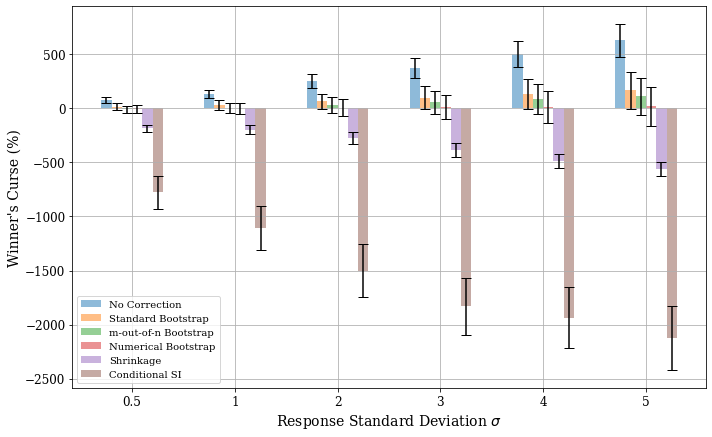

$\sigma=0.5$  $\sigma=1$  $\sigma=2$  $\sigma=3$  \
No Correction        Mean           78.00      130.72      249.76      374.32   
                     Median         80.32      124.98      258.49      386.94   
                     S.E.           14.78       19.89       33.02       47.37   
Standard Bootstrap   Mean           13.89       31.81       63.96       97.61   
                     Median          5.42       30.06       45.59       83.37   
                     S.E.           17.03       22.65       37.15       53.40   
m-out-of-n Bootstrap Mean           -9.93        3.23       29.11       57.21   
                     Median        -17.02        7.87       24.52       43.21   
                     S.E.           16.56       22.18       37.31       53.96   
Numerical Bootstrap  Mean           -7.16       -1.32        6.83       10.96   
                     Median        -16.84      -11.86       -5.26       -6.50   
                     S.E.           18.22       23.94       39.08       56.29   
Shrinkage            Mean         -185.85     -196.94     -276.92     -384.12   
                     Median       -169.36     -183.26     -255.76     -387.54   
                     S.E.           15.79       19.53       27.27       31.74   
Conditional SI       Mean         -778.27    -1106.05    -1502.88    -1831.24   
                     Median       -564.30     -805.94    -1262.16    -1591.80   
                     S.E.           78.54      104.41      125.60      135.18   

                             $\sigma=4$  $\sigma=5$  
No Correction        Mean        501.77      630.13  
                     Median      519.39      642.96  
                     S.E.         62.23       77.25  
Standard Bootstrap   Mean        135.09      166.42  
                     Median      121.50      176.77  
                     S.E.         70.08       87.07  
m-out-of-n Bootstrap Mean         88.72      111.44  
                     Median       90.82      120.23  
                     S.E.         71.18       88.08  
Numerical Bootstrap  Mean         13.51       18.17  
                     Median       -7.00        2.42  
                     S.E.         74.14       91.57  
Shrinkage            Mean       -484.85     -565.19  
                     Median     -484.94     -571.05  
                     S.E.         33.26       32.78  
Conditional SI       Mean      -1937.45    -2127.18  
                     Median    -1770.98    -2037.11  
                     S.E.        143.31      151.48

In [47]:
# parameters
optimizer_key = 'rank_and_select'
result_dict = response_std_result_dict.copy()
delta_tau = dgp_params['base_effect_vars'][1].mean - dgp_params['base_effect_vars'][0].mean

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys() if est_key != 'sample_splitting'
]

# For each delta tau value
for response_std in response_std_list:
    data[response_std] = {}

    data[response_std]['No Correction'] = {
        'Mean': 100 / delta_tau * result_dict[response_std][f'{optimizer_key}_nc_wc_avg'],
        'Median': 100 / delta_tau * np.nanmedian(result_dict[response_std][f'{optimizer_key}_nc_wc_arr']),
        'S.E.': 100 / delta_tau * result_dict[response_std][f'{optimizer_key}_nc_wc_se']
    }
    
    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys() if k != 'sample_splitting']):
        est_name = estimator_names[i+1]
        
        # Extract values
        mean_wc = 100 / delta_tau * result_dict[response_std][f'{optimizer_key}_{est_key}_wc_avg']
        median_wc = 100 / delta_tau * np.nanmedian(result_dict[response_std][f'{optimizer_key}_{est_key}_wc_arr'])
        se_wc = 100 / delta_tau * result_dict[response_std][f'{optimizer_key}_{est_key}_wc_se']
        
        # Store in nested dictionary
        data[response_std][est_name] = {
            'Mean': mean_wc, 'Median': median_wc, 'S.E.': se_wc
        }

# Create the MultiIndex DataFrame
index = pd.MultiIndex.from_product([
    estimator_names, ['Mean', 'Median', 'S.E.']
])

# Prepare data for DataFrame
df_data = []
for response_std in response_std_list:
    column_data = []
    for est_name in estimator_names:
        for stat in ['Mean', 'Median', 'S.E.']:
            column_data.append(data[response_std][est_name][stat])
    df_data.append(column_data)

# Create DataFrame
wc_stats_df = pd.DataFrame(
    np.array(df_data).T,
    index=index,
    columns=[r'$\sigma={}$'.format(p) for p in response_std_list]
)


""" 
Visualize the Winner's Curse as a function of the treatment effect difference
"""

# plot the winner's curse as a function of the number of experiments
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

n_estimators = len(estimators_dict.keys())
bar_positions = np.arange(len(response_std_list))
bar_width = 0.1 * n_estimators


# plot the bars
for idx, estimator in enumerate(estimator_names):
    
    bar_values = [data[p][estimator]['Mean'] for p in response_std_list]
    bar_errors = [1.96 * data[p][estimator]['S.E.'] for p in response_std_list]

    ax.bar(
        bar_positions - bar_width / 2 + idx * bar_width / n_estimators + bar_width / 2 / n_estimators,
        bar_values, yerr=bar_errors, capsize=5,
        label=estimator, alpha=0.5, width=bar_width / n_estimators
    )

ax.set_xlabel(r'Response Standard Deviation $\sigma$', fontsize=axis_label_size)
ax.set_ylabel('Winner\'s Curse (%)', fontsize=axis_label_size)
ax.set_xticks(
    np.arange(len(response_std_list)), labels=response_std_list, 
)
ax.tick_params(axis='both', labelsize=tick_label_size)
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()

# delete all variables in this cell
del data, estimator_names, df_data, estimator, idx, bar_positions, bar_width, bar_values, bar_errors, n_estimators, optimizer_key
del result_dict

# Display the DataFrame
wc_stats_df.round(2)

In [48]:
print(wc_stats_df.map(lambda x: f'{x:.2f}\%').style.to_latex())

\begin{tabular}{llllllll}
 &  & $\sigma=0.5$ & $\sigma=1$ & $\sigma=2$ & $\sigma=3$ & $\sigma=4$ & $\sigma=5$ \\
\multirow[c]{3}{*}{No Correction} & Mean & 78.00\% & 130.72\% & 249.76\% & 374.32\% & 501.77\% & 630.13\% \\
 & Median & 80.32\% & 124.98\% & 258.49\% & 386.94\% & 519.39\% & 642.96\% \\
 & S.E. & 14.78\% & 19.89\% & 33.02\% & 47.37\% & 62.23\% & 77.25\% \\
\multirow[c]{3}{*}{Standard Bootstrap} & Mean & 13.89\% & 31.81\% & 63.96\% & 97.61\% & 135.09\% & 166.42\% \\
 & Median & 5.42\% & 30.06\% & 45.59\% & 83.37\% & 121.50\% & 176.77\% \\
 & S.E. & 17.03\% & 22.65\% & 37.15\% & 53.40\% & 70.08\% & 87.07\% \\
\multirow[c]{3}{*}{m-out-of-n Bootstrap} & Mean & -9.93\% & 3.23\% & 29.11\% & 57.21\% & 88.72\% & 111.44\% \\
 & Median & -17.02\% & 7.87\% & 24.52\% & 43.21\% & 90.82\% & 120.23\% \\
 & S.E. & 16.56\% & 22.18\% & 37.31\% & 53.96\% & 71.18\% & 88.08\% \\
\multirow[c]{3}{*}{Numerical Bootstrap} & Mean & -7.16\% & -1.32\% & 6.83\% & 10.96\% & 13.51\% & 18.17\% \\
 & Media

## Functional Form

In [18]:
optimization_params = {
    'rank_and_select': {
        'optimizer': optimize, 'params': {}, 'display_name': 'Rank and Select'
    }
}

dgp_params = {
    'base_effect_vars': [PointMass(1), PointMass(1.1)], 
    'cust_feat_var': UnivariateGaussian(0, 1), 
    'char_func': None, 
    'noise_var': UnivariateGaussian(0, 1), 
    'response_type': 'continuous', 
    'dgp_seed': 0
}

data_params = {'sample_size': 100, 'targ_sample_size': 100} 

experiment_params = {
    'n_repeats': 500, 
    'estimator': {
        'estimator': CausalForestDML, 
        'params': {
            'n_treatments': len(dgp_params['base_effect_vars']), 
            'model_t': LogisticRegression(C=0.01), 
            'model_y': Lasso(alpha=0.01), 
            'n_estimators': 100, 
            'max_depth': 5, 
            'n_jobs': -1, 
            'discrete_treatment': True
        }
    }
}

estimators_dict = {
    'sample_splitting': {
        'estimator': sample_splitting_estimate, 
        'params': {'estimation_split': 0.5, }, 
        'display_name': 'Sample Splitting', 
    }, 
    'standard_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 100, 'n_jobs': -1}, 
        'display_name': 'Standard Bootstrap'
    },
    'mn_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'bootstrap_method': 'm_out_of_n', 'n_bootstraps': 100, 'power': 0.95, 'n_jobs': -1}, 
        'display_name': 'm-out-of-n Bootstrap'
    },
    'num_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'bootstrap_method': 'numerical', 'n_bootstraps': 100, 'power': -0.45, 'n_jobs': -1}, 
        'display_name': 'Numerical Bootstrap'
    }, 
    'bayes_normal': {
        'estimator': bayes_estimate, 
        'params': {'prior': 'normal', 'prior_mean': 0.0, 'prior_std': 1.0},
        'display_name': 'Shrinkage'
    }, 
    # 'eb_spike_slab': {
    #     'estimator': empirical_bayes_estimate, 
    #     'params': {'prior': 'spike_slab', 'pi': 0.5},
    #     'display_name': 'EB (Spike-and-Slab)'
    # }, 
    'conditional_si': {
        'estimator': selective_inference_estimate,
        'params': {'method': 'conditional', 'quantile': 0.5, 'n_jobs': -1}, 
        'display_name': 'Conditional SI'
    }, 
    # 'hybrid_si': {
    #     'estimator': selective_inference_estimate,
    #     'params': {'method': 'hybrid', 'quantile': 0.5, 'n_jobs': -1}, 
    #     'display_name': 'Hybrid SI'
    # }, 
}

char_func_dict = {
    r'$x$': lambda x: x,
    r'$x^2 + x$': lambda x: x**2 + x,
    r'$x^3$': lambda x: x**3,
    r'$|x|$': lambda x: np.abs(x),
}

In [ ]:
char_func_result_dict = {k: None for k in char_func_dict.keys()}
for char_func in char_func_dict.keys():
    print(f'\nCharacterizing Function= {char_func}')

    dgp_params['char_func'] = char_func_dict[char_func]

    result_records = repeated_experiment(
        optimization_params=optimization_params, 
        dgp_params=dgp_params, 
        data_params=data_params, 
        experiment_params=experiment_params,
        estimators_dict=estimators_dict,
        verbose=True,
        n_jobs=-1
    )

    char_func_result_dict[char_func] = calculate_winners_curse_measures(
        result_records=result_records, 
        optimization_params=optimization_params, 
        estimators_dict=estimators_dict, 
        data_params=data_params
    )



Characterizing Function= $x$
Running 500 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:  7.9min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed: 22.0min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed: 28.0min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Characterizing Function= $x^2 + x$
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:  7.9min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed: 22.0min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed: 28.1min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Characterizing Function= $x^3$
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:  8.0min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed: 22.1min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed: 28.3min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Characterizing Function= $|x|$
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:  8.1min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed: 22.3min
A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed: 28.4min finished


In [19]:
# with open('results/targeting_char_func.pkl', 'wb') as f:
#     pickle.dump(char_func_result_dict, f)

with open('results/targeting_char_func.pkl', 'rb') as f:
    char_func_result_dict = pickle.load(f)

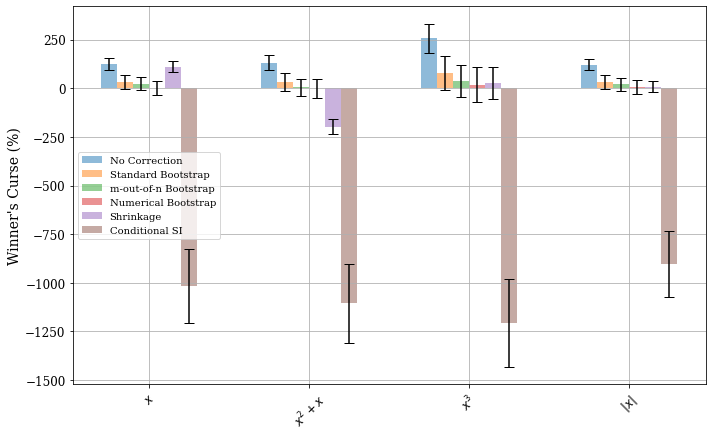

$x$  $x^2 + x$    $x^3$   $|x|$
No Correction        Mean     125.47     130.72   256.19  121.94
                     Median   128.89     124.98   238.22  124.15
                     S.E.      15.77      19.89    38.89   15.42
Standard Bootstrap   Mean      31.55      32.09    77.28   32.67
                     Median    25.70      23.07    75.23   25.32
                     S.E.      17.83      22.74    44.02   17.35
m-out-of-n Bootstrap Mean      24.20       4.35    35.93   19.63
                     Median    21.86       1.48    53.11   12.98
                     S.E.      18.03      22.33    42.15   17.55
Numerical Bootstrap  Mean       1.07      -0.90    17.61    4.61
                     Median    -5.48     -14.15    32.58   -2.10
                     S.E.      18.65      23.91    46.12   18.25
Shrinkage            Mean     110.57    -196.94    28.95    7.45
                     Median   113.30    -183.26    56.88   10.84
                     S.E.      14.60      19.53    42.20   14.37
Conditional SI       Mean   -1016.36   -1106.05 -1206.76 -904.28
                     Median  -757.70    -805.94  -883.39 -666.50
                     S.E.      96.28     104.41   116.08   85.93

In [20]:
# parameters
optimizer_key = 'rank_and_select'
result_dict = char_func_result_dict.copy()
delta_tau = dgp_params['base_effect_vars'][1].mean - dgp_params['base_effect_vars'][0].mean

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys() if est_key != 'sample_splitting'
]

# For each delta tau value
for char_func in char_func_dict.keys():
    data[char_func] = {}

    data[char_func]['No Correction'] = {
        'Mean': 100 / delta_tau * result_dict[char_func][f'{optimizer_key}_nc_wc_avg'],
        'Median': 100 / delta_tau * np.nanmedian(result_dict[char_func][f'{optimizer_key}_nc_wc_arr']),
        'S.E.': 100 / delta_tau * result_dict[char_func][f'{optimizer_key}_nc_wc_se']
    }
    
    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys() if k != 'sample_splitting']):
        est_name = estimator_names[i+1]
        
        # Extract values
        mean_wc = 100 / delta_tau * result_dict[char_func][f'{optimizer_key}_{est_key}_wc_avg']
        median_wc = 100 / delta_tau * np.nanmedian(result_dict[char_func][f'{optimizer_key}_{est_key}_wc_arr'])
        se_wc = 100 / delta_tau * result_dict[char_func][f'{optimizer_key}_{est_key}_wc_se']
        
        # Store in nested dictionary
        data[char_func][est_name] = {
            'Mean': mean_wc, 'Median': median_wc, 'S.E.': se_wc
        }

# Create the MultiIndex DataFrame
index = pd.MultiIndex.from_product([
    estimator_names, ['Mean', 'Median', 'S.E.']
])

# Prepare data for DataFrame
df_data = []
for noise_dstn in char_func_dict.keys():
    column_data = []
    for est_name in estimator_names:
        for stat in ['Mean', 'Median', 'S.E.']:
            column_data.append(data[noise_dstn][est_name][stat])
    df_data.append(column_data)

# Create DataFrame
wc_stats_df = pd.DataFrame(
    np.array(df_data).T,
    index=index,
    columns=list(char_func_dict.keys())
)


""" 
Visualize the Winner's Curse as a function of the treatment effect difference
"""

# plot the winner's curse as a function of the number of experiments
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

n_estimators = len(estimators_dict.keys())
bar_positions = np.arange(len(char_func_dict.keys()))
bar_width = 0.1 * n_estimators


# plot the bars
for idx, estimator in enumerate(estimator_names):
    
    bar_values = [data[p][estimator]['Mean'] for p in char_func_dict.keys()]
    bar_errors = [1.96 * data[p][estimator]['S.E.'] for p in char_func_dict.keys()]

    ax.bar(
        bar_positions - bar_width / 2 + idx * bar_width / n_estimators + bar_width / 2 / n_estimators,
        bar_values, yerr=bar_errors, capsize=5,
        label=estimator, alpha=0.5, width=bar_width / n_estimators
    )

ax.set_ylabel('Winner\'s Curse (%)', fontsize=axis_label_size)
ax.set_xticks(
    np.arange(len(char_func_dict.keys())), 
    labels=char_func_dict.keys(), 
    rotation=45
)
ax.tick_params(axis='both', labelsize=tick_label_size)
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()

# delete all variables in this cell
del data, estimator_names, df_data, estimator, idx, bar_positions, bar_width, bar_values, bar_errors, n_estimators, optimizer_key
del result_dict

# Display the DataFrame
wc_stats_df.round(2)

In [22]:
print(wc_stats_df.map(lambda x: f'{x:.2f}\%').style.to_latex())

\begin{tabular}{llllll}
 &  & $x$ & $x^2 + x$ & $x^3$ & $|x|$ \\
\multirow[c]{3}{*}{No Correction} & Mean & 125.47\% & 130.72\% & 256.19\% & 121.94\% \\
 & Median & 128.89\% & 124.98\% & 238.22\% & 124.15\% \\
 & S.E. & 15.77\% & 19.89\% & 38.89\% & 15.42\% \\
\multirow[c]{3}{*}{Standard Bootstrap} & Mean & 31.55\% & 32.09\% & 77.28\% & 32.67\% \\
 & Median & 25.70\% & 23.07\% & 75.23\% & 25.32\% \\
 & S.E. & 17.83\% & 22.74\% & 44.02\% & 17.35\% \\
\multirow[c]{3}{*}{m-out-of-n Bootstrap} & Mean & 24.20\% & 4.35\% & 35.93\% & 19.63\% \\
 & Median & 21.86\% & 1.48\% & 53.11\% & 12.98\% \\
 & S.E. & 18.03\% & 22.33\% & 42.15\% & 17.55\% \\
\multirow[c]{3}{*}{Numerical Bootstrap} & Mean & 1.07\% & -0.90\% & 17.61\% & 4.61\% \\
 & Median & -5.48\% & -14.15\% & 32.58\% & -2.10\% \\
 & S.E. & 18.65\% & 23.91\% & 46.12\% & 18.25\% \\
\multirow[c]{3}{*}{Shrinkage} & Mean & 110.57\% & -196.94\% & 28.95\% & 7.45\% \\
 & Median & 113.30\% & -183.26\% & 56.88\% & 10.84\% \\
 & S.E. & 14.60\% & 19

## Noise Distribution

In [51]:
optimization_params = {
    'rank_and_select': {
        'optimizer': optimize, 'params': {}, 'display_name': 'Rank and Select'
    }
}

dgp_params = {
    'base_effect_vars': [PointMass(1), PointMass(1.1)], 
    'cust_feat_var': UnivariateGaussian(0, 1), 
    'char_func': lambda x: x**2 + x, 
    'noise_var': None, 
    'response_type': 'continuous', 
    'dgp_seed': 0
}

data_params = {'sample_size': 100, 'targ_sample_size': 100} 

experiment_params = {
    'n_repeats': 500, 
    'estimator': {
        'estimator': CausalForestDML, 
        'params': {
            'n_treatments': len(dgp_params['base_effect_vars']), 
            'model_t': LogisticRegression(C=0.01), 
            'model_y': Lasso(alpha=0.01), 
            'n_estimators': 100, 
            'max_depth': 5, 
            'n_jobs': -1, 
            'discrete_treatment': True
        }
    }
}

estimators_dict = {
    'sample_splitting': {
        'estimator': sample_splitting_estimate, 
        'params': {'estimation_split': 0.5, }, 
        'display_name': 'Sample Splitting', 
    }, 
    'standard_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 100, 'n_jobs': -1}, 
        'display_name': 'Standard Bootstrap'
    },
    'mn_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'bootstrap_method': 'm_out_of_n', 'n_bootstraps': 100, 'power': 0.95, 'n_jobs': -1}, 
        'display_name': 'm-out-of-n Bootstrap'
    },
    'num_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'bootstrap_method': 'numerical', 'n_bootstraps': 100, 'power': -0.45, 'n_jobs': -1}, 
        'display_name': 'Numerical Bootstrap'
    }, 
    'bayes_normal': {
        'estimator': bayes_estimate, 
        'params': {'prior': 'normal', 'prior_mean': 0.0, 'prior_std': 1.0},
        'display_name': 'Shrinkage'
    }, 
    # 'eb_spike_slab': {
    #     'estimator': empirical_bayes_estimate, 
    #     'params': {'prior': 'spike_slab', 'pi': 0.5},
    #     'display_name': 'EB (Spike-and-Slab)'
    # }, 
    'conditional_si': {
        'estimator': selective_inference_estimate,
        'params': {'method': 'conditional', 'quantile': 0.5, 'n_jobs': -1}, 
        'display_name': 'Conditional SI'
    }, 
    # 'hybrid_si': {
    #     'estimator': selective_inference_estimate,
    #     'params': {'method': 'hybrid', 'quantile': 0.5, 'n_jobs': -1}, 
    #     'display_name': 'Hybrid SI'
    # }, 
}

noise_dstn_dict = {
    'Normal(0, 1)': UnivariateGaussian(0, std=1),
    'Uniform($-\sqrt{3}$, $-\sqrt{3}$)': Uniform(-3**0.5, 3**0.5),
    'Student T (Dof = 100)': StudentT(100), 
    r'Laplace(0, $1/\sqrt{2}$)': Laplace(0, 1 / np.sqrt(2)), 
    r'Logistic(0, $\sqrt{3} / \pi$)': Logistic(0, np.sqrt(3) / np.pi), 
}

In [ ]:


noise_dstn_result_dict = {k: None for k in noise_dstn_dict.keys()}

for noise_dstn in noise_dstn_dict.keys():
    print(f'\nNoise Distribution= {noise_dstn}')

    dgp_params['noise_var'] = noise_dstn_dict[noise_dstn]

    result_records = repeated_experiment(
        optimization_params=optimization_params, 
        dgp_params=dgp_params, 
        data_params=data_params, 
        experiment_params=experiment_params,
        estimators_dict=estimators_dict,
        verbose=True,
        n_jobs=-1
    )

    noise_dstn_result_dict[noise_dstn] = calculate_winners_curse_measures(
        result_records=result_records, 
        optimization_params=optimization_params, 
        estimators_dict=estimators_dict, 
        data_params=data_params
    )

In [53]:
# with open('results/targeting_noise_dstn.pkl', 'wb') as f:
#     pickle.dump(noise_dstn_result_dict, f)

with open('results/targeting_noise_dstn.pkl', 'rb') as f:
    noise_dstn_result_dict = pickle.load(f)

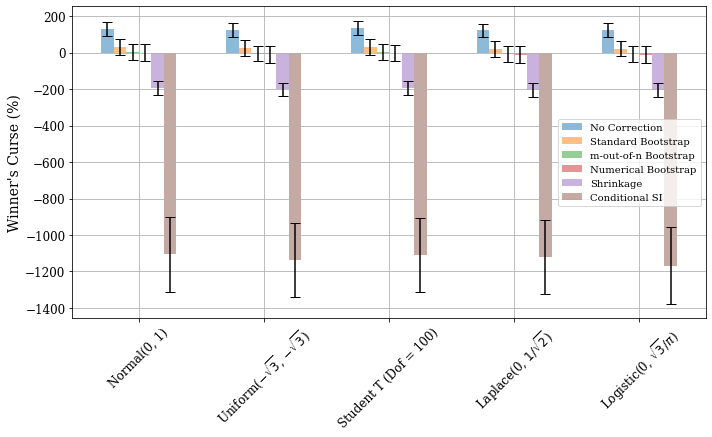

Normal(0, 1)  Uniform($-\sqrt{3}$, $-\sqrt{3}$)  \
No Correction        Mean          130.72                             123.98   
                     Median        124.98                             121.40   
                     S.E.           19.89                              18.68   
Standard Bootstrap   Mean           31.80                              23.66   
                     Median         29.59                              24.07   
                     S.E.           22.69                              21.83   
m-out-of-n Bootstrap Mean            3.90                              -7.11   
                     Median          3.04                              -8.46   
                     S.E.           22.36                              21.41   
Numerical Bootstrap  Mean           -1.53                             -10.12   
                     Median         -8.34                             -13.45   
                     S.E.           24.11                              23.02   
Shrinkage            Mean         -196.94                            -201.72   
                     Median       -183.26                            -191.91   
                     S.E.           19.53                              19.09   
Conditional SI       Mean        -1106.05                           -1137.39   
                     Median       -805.94                            -882.29   
                     S.E.          104.41                             103.35   

                             Student T (Dof = 100)  Laplace(0, $1/\sqrt{2}$)  \
No Correction        Mean                   136.28                    121.70   
                     Median                 137.43                    122.22   
                     S.E.                    19.77                     19.01   
Standard Bootstrap   Mean                    31.26                     20.98   
                     Median                  22.55                     12.08   
                     S.E.                    22.49                     21.88   
m-out-of-n Bootstrap Mean                     4.38                     -7.55   
                     Median                 -13.44                    -24.71   
                     S.E.                    21.79                     21.58   
Numerical Bootstrap  Mean                    -2.44                    -11.03   
                     Median                 -13.96                    -19.02   
                     S.E.                    23.58                     23.23   
Shrinkage            Mean                  -193.92                   -207.46   
                     Median                -189.32                   -199.11   
                     S.E.                    19.01                     19.33   
Conditional SI       Mean                 -1108.87                  -1118.89   
                     Median                -832.05                   -821.60   
                     S.E.                   103.63                    103.14   

                             Logistic(0, $\sqrt{3} / \pi$)  
No Correction        Mean                           122.15  
                     Median                         122.99  
                     S.E.                            18.94  
Standard Bootstrap   Mean                            22.14  
                     Median                          14.74  
                     S.E.                            21.99  
m-out-of-n Bootstrap Mean                            -7.37  
                     Median                         -21.08  
                     S.E.                            21.45  
Numerical Bootstrap  Mean                           -12.14  
                     Median                         -21.07  
                     S.E.                            23.13  
Shrinkage            Mean                          -206.61  
                     Median                        -197.24  
                     S.E.                            19.35  
Conditional

In [54]:
# parameters
optimizer_key = 'rank_and_select'
result_dict = noise_dstn_result_dict.copy()
delta_tau = dgp_params['base_effect_vars'][1].mean - dgp_params['base_effect_vars'][0].mean

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys() if est_key != 'sample_splitting'
]

# For each delta tau value
for noise_dstn in noise_dstn_dict.keys():
    data[noise_dstn] = {}

    data[noise_dstn]['No Correction'] = {
        'Mean': 100 / delta_tau * result_dict[noise_dstn][f'{optimizer_key}_nc_wc_avg'],
        'Median': 100 / delta_tau * np.nanmedian(result_dict[noise_dstn][f'{optimizer_key}_nc_wc_arr']),
        'S.E.': 100 / delta_tau * result_dict[noise_dstn][f'{optimizer_key}_nc_wc_se']
    }
    
    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys() if k != 'sample_splitting']):
        est_name = estimator_names[i+1]
        
        # Extract values
        mean_wc = 100 / delta_tau * result_dict[noise_dstn][f'{optimizer_key}_{est_key}_wc_avg']
        median_wc = 100 / delta_tau * np.nanmedian(result_dict[noise_dstn][f'{optimizer_key}_{est_key}_wc_arr'])
        se_wc = 100 / delta_tau * result_dict[noise_dstn][f'{optimizer_key}_{est_key}_wc_se']
        
        # Store in nested dictionary
        data[noise_dstn][est_name] = {
            'Mean': mean_wc, 'Median': median_wc, 'S.E.': se_wc
        }

# Create the MultiIndex DataFrame
index = pd.MultiIndex.from_product([
    estimator_names, ['Mean', 'Median', 'S.E.']
])

# Prepare data for DataFrame
df_data = []
for noise_dstn in noise_dstn_dict.keys():
    column_data = []
    for est_name in estimator_names:
        for stat in ['Mean', 'Median', 'S.E.']:
            column_data.append(data[noise_dstn][est_name][stat])
    df_data.append(column_data)

# Create DataFrame
wc_stats_df = pd.DataFrame(
    np.array(df_data).T,
    index=index,
    columns=list(noise_dstn_dict.keys())
)


""" 
Visualize the Winner's Curse as a function of the treatment effect difference
"""

# plot the winner's curse as a function of the number of experiments
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

n_estimators = len(estimators_dict.keys())
bar_positions = np.arange(len(noise_dstn_dict.keys()))
bar_width = 0.1 * n_estimators


# plot the bars
for idx, estimator in enumerate(estimator_names):
    
    bar_values = [data[p][estimator]['Mean'] for p in noise_dstn_dict.keys()]
    bar_errors = [1.96 * data[p][estimator]['S.E.'] for p in noise_dstn_dict.keys()]

    ax.bar(
        bar_positions - bar_width / 2 + idx * bar_width / n_estimators + bar_width / 2 / n_estimators,
        bar_values, yerr=bar_errors, capsize=5,
        label=estimator, alpha=0.5, width=bar_width / n_estimators
    )

ax.set_ylabel('Winner\'s Curse (%)', fontsize=axis_label_size)
ax.set_xticks(
    np.arange(len(noise_dstn_dict.keys())), 
    labels=noise_dstn_dict.keys(), 
    rotation=45
)
ax.tick_params(axis='both', labelsize=tick_label_size)
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()

# delete all variables in this cell
del data, estimator_names, df_data, estimator, idx, bar_positions, bar_width, bar_values, bar_errors, n_estimators, optimizer_key
del result_dict

# Display the DataFrame
wc_stats_df.round(2)

In [55]:
print(wc_stats_df.map(lambda x: f'{x:.2f}\%').style.to_latex())

\begin{tabular}{lllllll}
 &  & Normal(0, 1) & Uniform($-\sqrt{3}$, $-\sqrt{3}$) & Student T (Dof = 100) & Laplace(0, $1/\sqrt{2}$) & Logistic(0, $\sqrt{3} / \pi$) \\
\multirow[c]{3}{*}{No Correction} & Mean & 130.72\% & 123.98\% & 136.28\% & 121.70\% & 122.15\% \\
 & Median & 124.98\% & 121.40\% & 137.43\% & 122.22\% & 122.99\% \\
 & S.E. & 19.89\% & 18.68\% & 19.77\% & 19.01\% & 18.94\% \\
\multirow[c]{3}{*}{Standard Bootstrap} & Mean & 31.80\% & 23.66\% & 31.26\% & 20.98\% & 22.14\% \\
 & Median & 29.59\% & 24.07\% & 22.55\% & 12.08\% & 14.74\% \\
 & S.E. & 22.69\% & 21.83\% & 22.49\% & 21.88\% & 21.99\% \\
\multirow[c]{3}{*}{m-out-of-n Bootstrap} & Mean & 3.90\% & -7.11\% & 4.38\% & -7.55\% & -7.37\% \\
 & Median & 3.04\% & -8.46\% & -13.44\% & -24.71\% & -21.08\% \\
 & S.E. & 22.36\% & 21.41\% & 21.79\% & 21.58\% & 21.45\% \\
\multirow[c]{3}{*}{Numerical Bootstrap} & Mean & -1.53\% & -10.12\% & -2.44\% & -11.03\% & -12.14\% \\
 & Median & -8.34\% & -13.45\% & -13.96\% & -19.02\% & 

## Multiple Treatments

In [61]:
optimization_params = {
    'rank_and_select': {
        'optimizer': optimize, 'params': {}, 'display_name': 'Rank and Select'
    }
}

dgp_params = {
    'base_effect_vars': None, 
    'cust_feat_var': UnivariateGaussian(0, 1), 
    'char_func': lambda x: x**2 + x, 
    'noise_var': UnivariateGaussian(0, 1), 
    'response_type': 'continuous', 
    'dgp_seed': 0
}

data_params = {'sample_size': 100, 'targ_sample_size': 100} 

experiment_params = {
    'n_repeats': 500, 
    'estimator': {
        'estimator': CausalForestDML, 
        'params': {
            'n_treatments': None, 
            'model_t': LogisticRegression(C=0.01), 
            'model_y': Lasso(alpha=0.01), 
            'n_estimators': 100, 
            'max_depth': 5, 
            'n_jobs': -1, 
            'discrete_treatment': True
        }
    }
}

estimators_dict = {
    'sample_splitting': {
        'estimator': sample_splitting_estimate, 
        'params': {'estimation_split': 0.5, }, 
        'display_name': 'Sample Splitting', 
    }, 
    'standard_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 100, 'n_jobs': -1}, 
        'display_name': 'Standard Bootstrap'
    },
    'mn_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'bootstrap_method': 'm_out_of_n', 'n_bootstraps': 100, 'power': 0.95, 'n_jobs': -1}, 
        'display_name': 'm-out-of-n Bootstrap'
    },
    'num_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'bootstrap_method': 'numerical', 'n_bootstraps': 100, 'power': -0.45, 'n_jobs': -1}, 
        'display_name': 'Numerical Bootstrap'
    }, 
    'bayes_normal': {
        'estimator': bayes_estimate, 
        'params': {'prior': 'normal', 'prior_mean': 0.0, 'prior_std': 1.0},
        'display_name': 'Shrinkage'
    }, 
    # 'eb_spike_slab': {
    #     'estimator': empirical_bayes_estimate, 
    #     'params': {'prior': 'spike_slab', 'pi': 0.5},
    #     'display_name': 'EB (Spike-and-Slab)'
    # }, 
    'conditional_si': {
        'estimator': selective_inference_estimate,
        'params': {'method': 'conditional', 'quantile': 0.5, 'n_jobs': -1}, 
        'display_name': 'Conditional SI'
    }, 
    # 'hybrid_si': {
    #     'estimator': selective_inference_estimate,
    #     'params': {'method': 'hybrid', 'quantile': 0.5, 'n_jobs': -1}, 
    #     'display_name': 'Hybrid SI'
    # }, 
}

n_treatments_list = [2, 4, 6, 8, 10]
delta_tau = 0.1

In [ ]:

n_treatments_result_dict = {n_treatments: None for n_treatments in n_treatments_list}

for n_treatments in n_treatments_list:
    print(f'\nNumber of Treatments= {n_treatments}')

    dgp_params['base_effect_vars'] = [PointMass(1 + i * delta_tau) for i in range(n_treatments)]
    experiment_params['estimator']['params']['n_treatments'] = n_treatments

    result_records = repeated_experiment(
        optimization_params=optimization_params, 
        dgp_params=dgp_params, 
        data_params=data_params, 
        experiment_params=experiment_params,
        estimators_dict=estimators_dict,
        verbose=True,
        n_jobs=-1
    )

    n_treatments_result_dict[n_treatments] = calculate_winners_curse_measures(
        result_records=result_records, 
        optimization_params=optimization_params, 
        estimators_dict=estimators_dict, 
        data_params=data_params
    )


Number of Treatments= 2
Running 500 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:  8.2min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed: 22.2min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed: 28.1min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Number of Treatments= 4
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed: 10.5min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed: 29.2min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed: 37.3min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Number of Treatments= 6
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed: 15.2min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed: 41.8min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed: 53.5min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Number of Treatments= 8
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed: 21.2min
A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed: 62.0min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed: 77.3min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Number of Treatments= 10
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed: 35.2min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed: 99.3min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed: 126.8min finished


In [58]:
# with open('results/targeting_n_treatments.pkl', 'wb') as f:
#     pickle.dump(n_treatments_result_dict, f)

with open('results/targeting_n_treatments.pkl', 'rb') as f:
    n_treatments_result_dict = pickle.load(f)

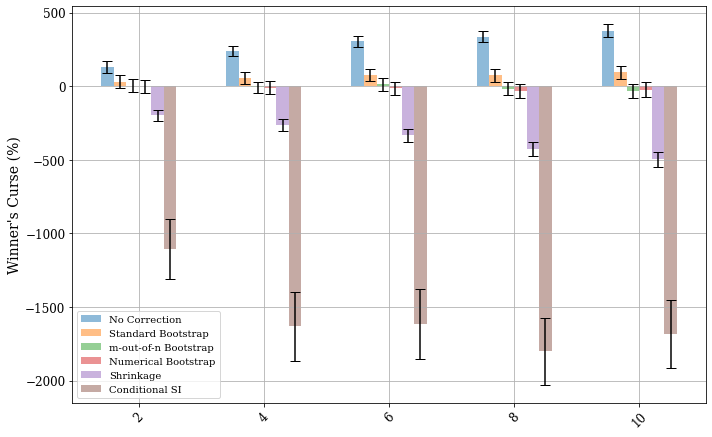

2        4        6        8        10
No Correction        Mean     130.72   237.25   306.94   337.95   378.93
                     Median   124.98   232.79   302.70   334.53   367.23
                     S.E.      19.89    17.55    19.22    19.70    21.10
Standard Bootstrap   Mean      30.91    57.44    76.25    76.11    94.85
                     Median    25.84    61.61    81.33    86.88    86.65
                     S.E.      22.65    20.03    21.78    22.37    23.70
m-out-of-n Bootstrap Mean       3.10    -7.29    13.39   -17.45   -33.32
                     Median     1.07   -12.31    15.10   -18.76   -40.12
                     S.E.      22.41    20.18    21.74    22.41    23.99
Numerical Bootstrap  Mean      -0.86    -8.21   -13.14   -31.16   -22.88
                     Median   -13.06    -5.30   -17.61   -22.89   -29.45
                     S.E.      24.03    21.34    23.35    24.07    25.08
Shrinkage            Mean    -196.94  -262.65  -333.77  -425.57  -497.17
                     Median  -183.26  -245.19  -325.31  -406.07  -484.73
                     S.E.      19.53    20.58    22.62    25.05    26.87
Conditional SI       Mean   -1106.05 -1630.71 -1613.49 -1800.97 -1681.72
                     Median  -805.94 -1388.19 -1343.46 -1641.86 -1474.48
                     S.E.     104.41   120.09   121.51   116.25   117.09

In [62]:
# parameters
optimizer_key = 'rank_and_select'
result_dict = n_treatments_result_dict.copy()
delta_tau = delta_tau

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys() if est_key != 'sample_splitting'
]

# For each delta tau value
for n_treatments in n_treatments_list:
    data[n_treatments] = {}

    data[n_treatments]['No Correction'] = {
        'Mean': 100 / delta_tau * result_dict[n_treatments][f'{optimizer_key}_nc_wc_avg'],
        'Median': 100 / delta_tau * np.nanmedian(result_dict[n_treatments][f'{optimizer_key}_nc_wc_arr']),
        'S.E.': 100 / delta_tau * result_dict[n_treatments][f'{optimizer_key}_nc_wc_se']
    }
    
    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys() if k != 'sample_splitting']):
        est_name = estimator_names[i+1]
        
        # Extract values
        mean_wc = 100 / delta_tau * result_dict[n_treatments][f'{optimizer_key}_{est_key}_wc_avg']
        median_wc = 100 / delta_tau * np.nanmedian(result_dict[n_treatments][f'{optimizer_key}_{est_key}_wc_arr'])
        se_wc = 100 / delta_tau * result_dict[n_treatments][f'{optimizer_key}_{est_key}_wc_se']
        
        # Store in nested dictionary
        data[n_treatments][est_name] = {
            'Mean': mean_wc, 'Median': median_wc, 'S.E.': se_wc
        }

# Create the MultiIndex DataFrame
index = pd.MultiIndex.from_product([
    estimator_names, ['Mean', 'Median', 'S.E.']
])

# Prepare data for DataFrame
df_data = []
for n_treatments in n_treatments_list:
    column_data = []
    for est_name in estimator_names:
        for stat in ['Mean', 'Median', 'S.E.']:
            column_data.append(data[n_treatments][est_name][stat])
    df_data.append(column_data)

# Create DataFrame
wc_stats_df = pd.DataFrame(
    np.array(df_data).T,
    index=index,
    columns=n_treatments_list
)


""" 
Visualize the Winner's Curse as a function of the treatment effect difference
"""

# plot the winner's curse as a function of the number of experiments
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

n_estimators = len(estimators_dict.keys())
bar_positions = np.arange(len(n_treatments_list))
bar_width = 0.1 * n_estimators


# plot the bars
for idx, estimator in enumerate(estimator_names):
    
    bar_values = [data[p][estimator]['Mean'] for p in n_treatments_list]
    bar_errors = [1.96 * data[p][estimator]['S.E.'] for p in n_treatments_list]

    ax.bar(
        bar_positions - bar_width / 2 + idx * bar_width / n_estimators + bar_width / 2 / n_estimators,
        bar_values, yerr=bar_errors, capsize=5,
        label=estimator, alpha=0.5, width=bar_width / n_estimators
    )

ax.set_ylabel('Winner\'s Curse (%)', fontsize=axis_label_size)
ax.set_xticks(
    np.arange(len(n_treatments_list)), 
    labels=n_treatments_list, 
    rotation=45
)
ax.tick_params(axis='both', labelsize=tick_label_size)
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()

# delete all variables in this cell
del data, estimator_names, df_data, estimator, idx, bar_positions, bar_width, bar_values, bar_errors, n_estimators, optimizer_key
del result_dict

# Display the DataFrame
wc_stats_df.round(2)

In [ ]:
print(wc_stats_df.map(lambda x: f'{x:.2f}\%').style.to_latex())

## Max Depth

In [23]:
optimization_params = {
    'rank_and_select': {
        'optimizer': optimize, 'params': {}, 'display_name': 'Rank and Select'
    }
}

dgp_params = {
    'base_effect_vars': [PointMass(1), PointMass(1.1)], 
    'cust_feat_var': UnivariateGaussian(0, 1), 
    'char_func': lambda x: x**2 + x, 
    'noise_var': UnivariateGaussian(0, 1), 
    'response_type': 'continuous', 
    'dgp_seed': 0
}

data_params = {'sample_size': 100, 'targ_sample_size': 100} 

experiment_params = {
    'n_repeats': 500, 
    'estimator': {
        'estimator': CausalForestDML, 
        'params': {
            'n_treatments': len(dgp_params['base_effect_vars']), 
            'model_t': LogisticRegression(C=0.01), 
            'model_y': Lasso(alpha=0.01), 
            'n_estimators': 100, 
            'max_depth': 5, 
            'n_jobs': -1, 
            'discrete_treatment': True
        }
    }
}

estimators_dict = {
    'sample_splitting': {
        'estimator': sample_splitting_estimate, 
        'params': {'estimation_split': 0.5, }, 
        'display_name': 'Sample Splitting', 
    }, 
    'standard_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 100, 'n_jobs': -1}, 
        'display_name': 'Standard Bootstrap'
    },
    'mn_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'bootstrap_method': 'm_out_of_n', 'n_bootstraps': 100, 'power': 0.95, 'n_jobs': -1}, 
        'display_name': 'm-out-of-n Bootstrap'
    },
    'num_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'bootstrap_method': 'numerical', 'n_bootstraps': 100, 'power': -0.45, 'n_jobs': -1}, 
        'display_name': 'Numerical Bootstrap'
    }, 
    'bayes_normal': {
        'estimator': bayes_estimate, 
        'params': {'prior': 'normal', 'prior_mean': 0.0, 'prior_std': 1.0},
        'display_name': 'Bayes (Normal)'
    }, 
    # 'eb_spike_slab': {
    #     'estimator': empirical_bayes_estimate, 
    #     'params': {'prior': 'spike_slab', 'pi': 0.5},
    #     'display_name': 'EB (Spike-and-Slab)'
    # }, 
    'conditional_si': {
        'estimator': selective_inference_estimate,
        'params': {'method': 'conditional', 'quantile': 0.5, 'n_jobs': -1}, 
        'display_name': 'Conditional SI'
    }, 
    # 'hybrid_si': {
    #     'estimator': selective_inference_estimate,
    #     'params': {'method': 'hybrid', 'quantile': 0.5, 'n_jobs': -1}, 
    #     'display_name': 'Hybrid SI'
    # }, 
}

max_depth_list = [2, 3, 4, 5, 6, 7, 8, 9, 10]

In [ ]:
max_depth_result_dict = {max_depth: None for max_depth in max_depth_list}

for max_depth in max_depth_list:
    print(f'\nMax Depth= {max_depth}')

    experiment_params['estimator']['params']['max_depth'] = max_depth

    result_records = repeated_experiment(
        optimization_params=optimization_params, 
        dgp_params=dgp_params, 
        data_params=data_params, 
        experiment_params=experiment_params,
        estimators_dict=estimators_dict,
        verbose=True,
        n_jobs=-1
    )

    max_depth_result_dict[max_depth] = calculate_winners_curse_measures(
        result_records=result_records, 
        optimization_params=optimization_params, 
        estimators_dict=estimators_dict, 
        data_params=data_params
    )

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Max Depth= 2
Running 500 experiments...


A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:  7.5min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed: 19.8min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed: 25.2min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Max Depth= 3
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:  7.4min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed: 20.5min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed: 25.6min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.


...

[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:  8.1min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed: 21.2min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed: 27.2min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Max Depth= 9
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:  7.6min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed: 21.4min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed: 27.1min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Max Depth= 10
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:  7.7min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed: 21.4min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed: 27.2min finished


In [24]:
# with open('results/targeting_max_depth.pkl', 'wb') as f:
#     pickle.dump(max_depth_result_dict, f)

with open('results/targeting_max_depth.pkl', 'rb') as f:
    max_depth_result_dict = pickle.load(f)

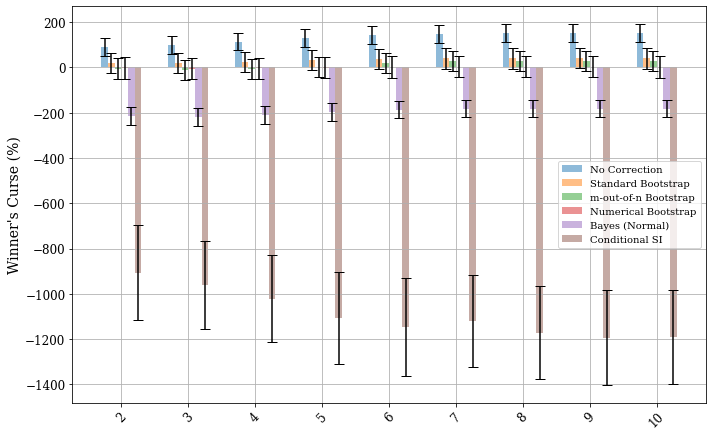

2       3        4        5        6   \
No Correction        Mean     89.63   98.91   114.42   130.72   143.38   
                     Median   99.54   98.25   114.00   124.98   142.82   
                     S.E.     20.51   19.91    19.81    19.89    20.05   
Standard Bootstrap   Mean     20.15   20.63    25.52    31.73    37.88   
                     Median   25.36   16.31    19.34    27.32    31.52   
                     S.E.     23.49   22.77    22.40    22.67    22.95   
m-out-of-n Bootstrap Mean     -5.56   -9.75    -7.51     2.57    18.78   
                     Median   -5.67  -11.65    -7.84    -1.51    19.45   
                     S.E.     23.53   22.64    22.35    22.34    22.55   
Numerical Bootstrap  Mean     -2.16   -5.39    -3.19    -1.50     1.99   
                     Median   -3.34  -11.90   -16.93    -8.82    -8.00   
                     S.E.     24.80   24.09    23.70    23.91    24.14   
Bayes (Normal)       Mean   -214.02 -218.39  -209.18  -196.94  -186.87   
                     Median -195.49 -198.88  -197.96  -183.26  -176.98   
                     S.E.     20.87   19.92    19.59    19.53    19.60   
Conditional SI       Mean   -906.68 -960.76 -1021.31 -1106.05 -1147.05   
                     Median -556.48 -679.29  -745.00  -805.94  -826.32   
                     S.E.    106.93   98.33    97.31   104.41   111.00   

                                  7        8        9        10  
No Correction        Mean     149.19   150.58   150.65   150.65  
                     Median   155.65   158.17   157.97   157.97  
                     S.E.      20.12    20.13    20.13    20.13  
Standard Bootstrap   Mean      40.51    40.46    40.61    40.46  
                     Median    32.92    33.01    35.30    35.42  
                     S.E.      23.06    23.09    22.99    22.99  
m-out-of-n Bootstrap Mean      27.29    28.77    29.33    29.95  
                     Median    24.84    27.04    25.38    33.04  
                     S.E.      22.74    22.76    22.79    22.82  
Numerical Bootstrap  Mean       4.32     3.53     3.96     3.33  
                     Median    -5.39    -4.05    -5.70    -4.52  
                     S.E.      24.32    24.31    24.31    24.31  
Bayes (Normal)       Mean    -182.45  -181.33  -181.29  -181.30  
                     Median  -174.82  -174.99  -175.18  -175.18  
                     S.E.      19.57    19.56    19.56    19.56  
Conditional SI       Mean   -1119.91 -1171.60 -1193.75 -1189.82  
                     Median  -837.10  -863.74  -866.87  -863.48  
                     S.E.     103.40   104.73   106.43   106.13

In [25]:
# parameters
optimizer_key = 'rank_and_select'
result_dict = max_depth_result_dict.copy()
delta_tau = dgp_params['base_effect_vars'][1].mean - dgp_params['base_effect_vars'][0].mean

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys() if est_key != 'sample_splitting'
]

# For each delta tau value
for max_depth in max_depth_list:
    data[max_depth] = {}

    data[max_depth]['No Correction'] = {
        'Mean': 100 / delta_tau * result_dict[max_depth][f'{optimizer_key}_nc_wc_avg'],
        'Median': 100 / delta_tau * np.nanmedian(result_dict[max_depth][f'{optimizer_key}_nc_wc_arr']),
        'S.E.': 100 / delta_tau * result_dict[max_depth][f'{optimizer_key}_nc_wc_se']
    }
    
    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys() if k != 'sample_splitting']):
        est_name = estimator_names[i+1]
        
        # Extract values
        mean_wc = 100 / delta_tau * result_dict[max_depth][f'{optimizer_key}_{est_key}_wc_avg']
        median_wc = 100 / delta_tau * np.nanmedian(result_dict[max_depth][f'{optimizer_key}_{est_key}_wc_arr'])
        se_wc = 100 / delta_tau * result_dict[max_depth][f'{optimizer_key}_{est_key}_wc_se']
        
        # Store in nested dictionary
        data[max_depth][est_name] = {
            'Mean': mean_wc, 'Median': median_wc, 'S.E.': se_wc
        }

# Create the MultiIndex DataFrame
index = pd.MultiIndex.from_product([
    estimator_names, ['Mean', 'Median', 'S.E.']
])

# Prepare data for DataFrame
df_data = []
for max_depth in max_depth_list:
    column_data = []
    for est_name in estimator_names:
        for stat in ['Mean', 'Median', 'S.E.']:
            column_data.append(data[max_depth][est_name][stat])
    df_data.append(column_data)

# Create DataFrame
wc_stats_df = pd.DataFrame(
    np.array(df_data).T,
    index=index,
    columns=max_depth_list
)


""" 
Visualize the Winner's Curse as a function of the treatment effect difference
"""

# plot the winner's curse as a function of the number of experiments
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

n_estimators = len(estimators_dict.keys())
bar_positions = np.arange(len(max_depth_list))
bar_width = 0.1 * n_estimators


# plot the bars
for idx, estimator in enumerate(estimator_names):
    
    bar_values = [data[p][estimator]['Mean'] for p in max_depth_list]
    bar_errors = [1.96 * data[p][estimator]['S.E.'] for p in max_depth_list]

    ax.bar(
        bar_positions - bar_width / 2 + idx * bar_width / n_estimators + bar_width / 2 / n_estimators,
        bar_values, yerr=bar_errors, capsize=5,
        label=estimator, alpha=0.5, width=bar_width / n_estimators
    )

ax.set_ylabel('Winner\'s Curse (%)', fontsize=axis_label_size)
ax.set_xticks(
    np.arange(len(max_depth_list)), 
    labels=max_depth_list, 
    rotation=45
)
ax.tick_params(axis='both', labelsize=tick_label_size)
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()

# delete all variables in this cell
del data, estimator_names, df_data, estimator, idx, bar_positions, bar_width, bar_values, bar_errors, n_estimators, optimizer_key
del result_dict

# Display the DataFrame
wc_stats_df.round(2)

In [27]:
print(wc_stats_df[[2, 4, 6, 8, 10]].map(lambda x: f'{x:.2f}\%').style.to_latex())

\begin{tabular}{lllllll}
 &  & 2 & 4 & 6 & 8 & 10 \\
\multirow[c]{3}{*}{No Correction} & Mean & 89.63\% & 114.42\% & 143.38\% & 150.58\% & 150.65\% \\
 & Median & 99.54\% & 114.00\% & 142.82\% & 158.17\% & 157.97\% \\
 & S.E. & 20.51\% & 19.81\% & 20.05\% & 20.13\% & 20.13\% \\
\multirow[c]{3}{*}{Standard Bootstrap} & Mean & 20.15\% & 25.52\% & 37.88\% & 40.46\% & 40.46\% \\
 & Median & 25.36\% & 19.34\% & 31.52\% & 33.01\% & 35.42\% \\
 & S.E. & 23.49\% & 22.40\% & 22.95\% & 23.09\% & 22.99\% \\
\multirow[c]{3}{*}{m-out-of-n Bootstrap} & Mean & -5.56\% & -7.51\% & 18.78\% & 28.77\% & 29.95\% \\
 & Median & -5.67\% & -7.84\% & 19.45\% & 27.04\% & 33.04\% \\
 & S.E. & 23.53\% & 22.35\% & 22.55\% & 22.76\% & 22.82\% \\
\multirow[c]{3}{*}{Numerical Bootstrap} & Mean & -2.16\% & -3.19\% & 1.99\% & 3.53\% & 3.33\% \\
 & Median & -3.34\% & -16.93\% & -8.00\% & -4.05\% & -4.52\% \\
 & S.E. & 24.80\% & 23.70\% & 24.14\% & 24.31\% & 24.31\% \\
\multirow[c]{3}{*}{Bayes (Normal)} & Mean & -214.02

In [6]:
optimization_params = {
    'rank_and_select': {
        'optimizer': optimize, 'params': {}, 'display_name': 'Rank and Select'
    }
}

dgp_params = {
    'base_effect_vars': [PointMass(1), PointMass(1.1)], 
    'cust_feat_var': UnivariateGaussian(0, 1), 
    'char_func': lambda x: x**2 + x, 
    'noise_var': UnivariateGaussian(0, 1), 
    'response_type': 'continuous', 
    'dgp_seed': 0
}

data_params = {'sample_size': 100, 'targ_sample_size': 100} 

experiment_params = {
    'n_repeats': 500, 
    'estimator': {
        'estimator': CausalForestDML, 
        'params': {
            'n_treatments': len(dgp_params['base_effect_vars']), 
            'model_t': LogisticRegression(C=0.01), 
            'model_y': Lasso(alpha=0.01), 
            'n_estimators': 100, 
            'max_depth': np.nan, 
            'n_jobs': -1, 
            'discrete_treatment': True
        }
    }
}

estimators_dict = {}

In [17]:
sample_size_list = [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]

max_depth_list = np.arange(2, 30, 2)

depth_size_result_dict = {(sample_size, max_depth): None for sample_size in sample_size_list for max_depth in max_depth_list}

for sample_size in sample_size_list:
    for max_depth in max_depth_list:
        print(f'\nSample Size= {sample_size}, Max Depth= {max_depth}')

        experiment_params['estimator']['params']['max_depth'] = max_depth
        data_params['sample_size'] = sample_size

        result_records = repeated_experiment(
            optimization_params=optimization_params, 
            dgp_params=dgp_params, 
            data_params=data_params, 
            experiment_params=experiment_params,
            estimators_dict=estimators_dict,
            verbose=False,
            n_jobs=-1
        )

        depth_size_result_dict[(sample_size, max_depth)] = calculate_winners_curse_measures(
            result_records=result_records, 
            optimization_params=optimization_params, 
            estimators_dict=estimators_dict, 
            data_params=data_params
        )


Sample Size= 100, Max Depth= 2

Sample Size= 100, Max Depth= 4

Sample Size= 100, Max Depth= 6

Sample Size= 100, Max Depth= 8

Sample Size= 100, Max Depth= 10

Sample Size= 100, Max Depth= 12

Sample Size= 100, Max Depth= 14

Sample Size= 100, Max Depth= 16

Sample Size= 100, Max Depth= 18

Sample Size= 100, Max Depth= 20

Sample Size= 100, Max Depth= 22

Sample Size= 100, Max Depth= 24

Sample Size= 100, Max Depth= 26

Sample Size= 100, Max Depth= 28

Sample Size= 200, Max Depth= 2

Sample Size= 200, Max Depth= 4

Sample Size= 200, Max Depth= 6

Sample Size= 200, Max Depth= 8

Sample Size= 200, Max Depth= 10

Sample Size= 200, Max Depth= 12

Sample Size= 200, Max Depth= 14

Sample Size= 200, Max Depth= 16

Sample Size= 200, Max Depth= 18

Sample Size= 200, Max Depth= 20

Sample Size= 200, Max Depth= 22

Sample Size= 200, Max Depth= 24

Sample Size= 200, Max Depth= 26

Sample Size= 200, Max Depth= 28

Sample Size= 300, Max Depth= 2

Sample Size= 300, Max Depth= 4

Sample Size= 300, M

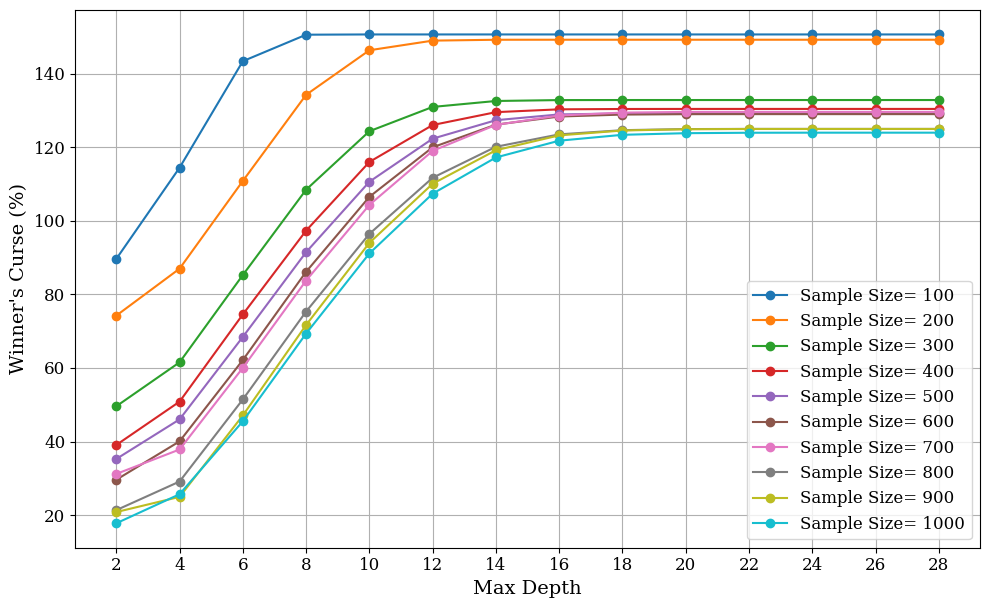

In [ ]:
delta_tau = dgp_params['base_effect_vars'][1].mean - dgp_params['base_effect_vars'][0].mean


fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

for sample_size in sample_size_list:
    data = []
    for max_depth in max_depth_list:
        data.append(depth_size_result_dict[(sample_size, max_depth)][f'rank_and_select_nc_wc_avg'] / delta_tau * 100)
    
    ax.plot(max_depth_list, data, label=f'Sample Size= {sample_size}', marker='o')

ax.set_xlabel('Max Depth', fontsize=axis_label_size)
ax.set_ylabel('Winner\'s Curse (%)', fontsize=axis_label_size)
ax.tick_params(axis='both', labelsize=tick_label_size)
ax.legend(fontsize=legend_label_size)
ax.set_xticks(max_depth_list, labels=max_depth_list)
ax.grid()
plt.tight_layout()
plt.show()


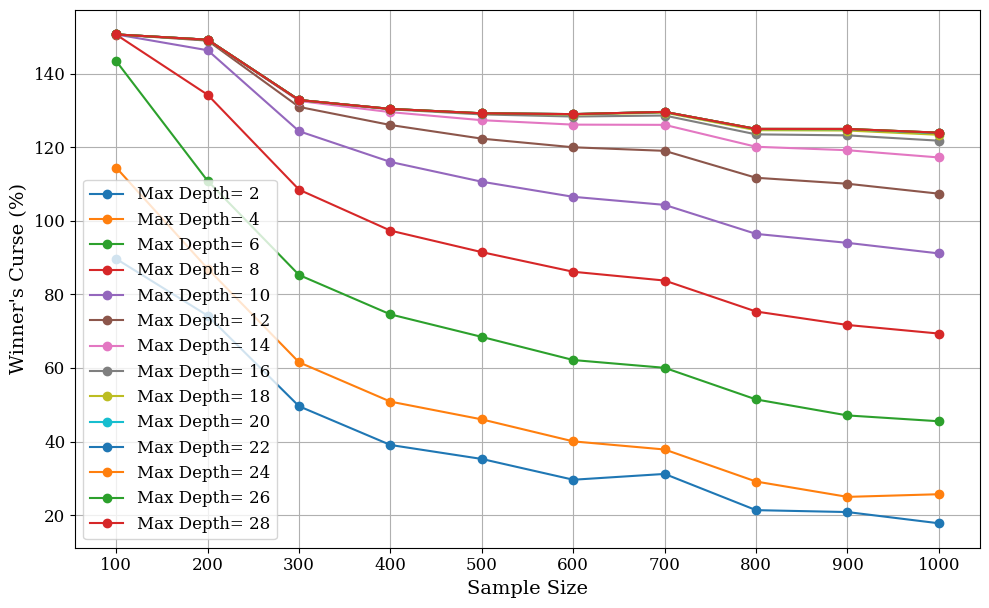

In [21]:
delta_tau = dgp_params['base_effect_vars'][1].mean - dgp_params['base_effect_vars'][0].mean


fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

for max_depth in max_depth_list:
    data = []
    for sample_size in sample_size_list:
        data.append(depth_size_result_dict[(sample_size, max_depth)][f'rank_and_select_nc_wc_avg'] / delta_tau * 100)
    
    ax.plot(sample_size_list, data, label=f'Max Depth= {max_depth}', marker='o')

ax.set_xlabel('Sample Size', fontsize=axis_label_size)
ax.set_ylabel('Winner\'s Curse (%)', fontsize=axis_label_size)
ax.tick_params(axis='both', labelsize=tick_label_size)
ax.legend(fontsize=legend_label_size)
ax.set_xticks(sample_size_list, labels=sample_size_list)
ax.grid()
plt.tight_layout()
plt.show()


In [16]:
optimization_params = {
    'rank_and_select': {
        'optimizer': optimize, 'params': {}, 'display_name': 'Rank and Select'
    }
}

dgp_params = {
    'base_effect_vars': [PointMass(1 + i * 0.1) for i in range(2)], 
    'cust_feat_var': UnivariateGaussian(0, 1), 
    'char_func': lambda x: x**2 + x, 
    'noise_var': UnivariateGaussian(0, 1), 
    'response_type': 'continuous', 
    'dgp_seed': 0
}

data_params = {'sample_size': None, 'targ_sample_size': 100} 

experiment_params = {
    'n_repeats': 500, 
    'estimator': {
        'estimator': CausalForestDML, 
        'params': {
            'n_treatments': len(dgp_params['base_effect_vars']), 
            'model_t': LogisticRegression(C=0.01), 
            'model_y': Lasso(alpha=0.01), 
            'n_estimators': 100, 
            'max_depth': None, 
            'n_jobs': -1, 
            'discrete_treatment': True
        }
    }
}

estimators_dict = {}

max_depth_list = [15, 20, 25, 30]
depth_sample_size_list = [1000, 5000, 10000, 15000, 20000]

In [17]:
depth_sample_size_result_dict = {(sample_size, max_depth): None for sample_size in depth_sample_size_list for max_depth in max_depth_list}

for sample_size in depth_sample_size_list:
    for max_depth in max_depth_list:
        print(f'\nSample Size= {sample_size}, Max Depth= {max_depth}')

        experiment_params['estimator']['params']['max_depth'] = max_depth
        data_params['sample_size'] = sample_size

        result_records = repeated_experiment(
            optimization_params=optimization_params, 
            dgp_params=dgp_params, 
            data_params=data_params, 
            experiment_params=experiment_params,
            estimators_dict=estimators_dict,
            verbose=False,
            n_jobs=-1
        )

        depth_sample_size_result_dict[(sample_size, max_depth)] = calculate_winners_curse_measures(
            result_records=result_records, 
            optimization_params=optimization_params, 
            estimators_dict=estimators_dict, 
            data_params=data_params
        )


Sample Size= 1000, Max Depth= 15

Sample Size= 1000, Max Depth= 20

Sample Size= 1000, Max Depth= 25

Sample Size= 1000, Max Depth= 30

Sample Size= 5000, Max Depth= 15

Sample Size= 5000, Max Depth= 20

Sample Size= 5000, Max Depth= 25

Sample Size= 5000, Max Depth= 30

Sample Size= 10000, Max Depth= 15

Sample Size= 10000, Max Depth= 20


A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.



Sample Size= 10000, Max Depth= 25

Sample Size= 10000, Max Depth= 30

Sample Size= 15000, Max Depth= 15

Sample Size= 15000, Max Depth= 20

Sample Size= 15000, Max Depth= 25

Sample Size= 15000, Max Depth= 30

Sample Size= 20000, Max Depth= 15

Sample Size= 20000, Max Depth= 20

Sample Size= 20000, Max Depth= 25

Sample Size= 20000, Max Depth= 30


In [18]:
with open('results/targeting_depth_sample_size.pkl', 'wb') as f:
    pickle.dump(depth_sample_size_result_dict, f)

with open('results/targeting_depth_sample_size.pkl', 'rb') as f:
    depth_sample_size_result_dict = pickle.load(f)

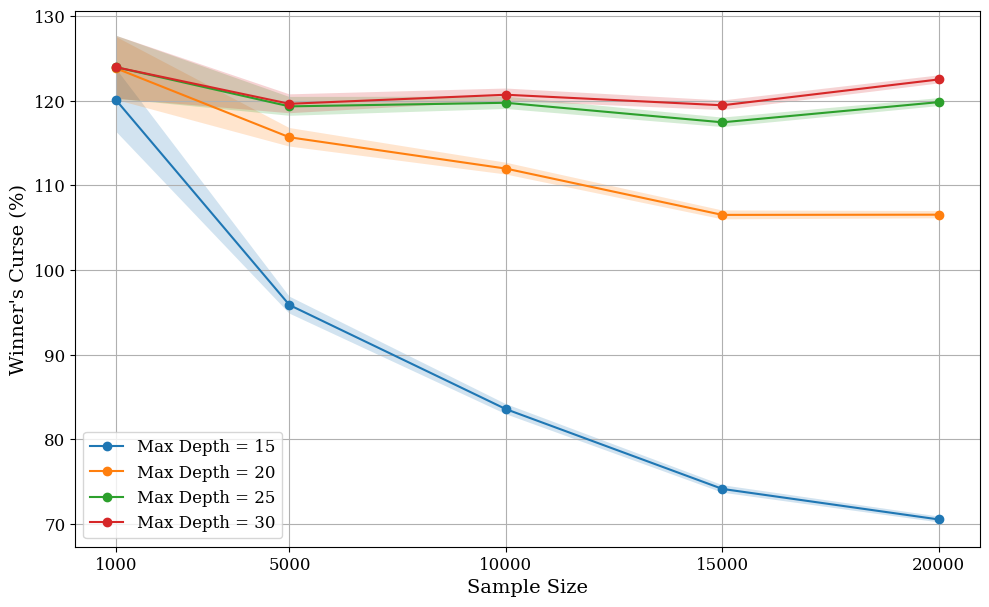

In [25]:
delta_tau = dgp_params['base_effect_vars'][1].mean - dgp_params['base_effect_vars'][0].mean

fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

for max_depth in max_depth_list:
    wc_avg_list = [result_dict['rank_and_select_nc_wc_avg'] * 100 / delta_tau for (_, depth), result_dict in depth_sample_size_result_dict.items() if depth == max_depth]
    wc_se_list = [result_dict['rank_and_select_nc_wc_se'] * 100 / delta_tau for (_, depth), result_dict in depth_sample_size_result_dict.items() if depth == max_depth]

    ax.plot(depth_sample_size_list, wc_avg_list, label=f'Max Depth = {max_depth}', marker='o')
    ax.fill_between(
        depth_sample_size_list, 
        np.array(wc_avg_list) - 1.96 * np.array(wc_se_list), 
        np.array(wc_avg_list) + 1.96 * np.array(wc_se_list), 
        alpha=0.2
    )

ax.set_xlabel('Sample Size', fontsize=axis_label_size)
ax.set_ylabel('Winner\'s Curse (%)', fontsize=axis_label_size)
ax.tick_params(axis='both', labelsize=tick_label_size)
ax.legend(fontsize=legend_label_size)

ax.set_xticks(depth_sample_size_list, labels=depth_sample_size_list)
ax.grid()
plt.tight_layout()
plt.show()

In [30]:
# print policy value estimates and true policy value
for max_depth in max_depth_list:
    for sample_size in depth_sample_size_list:
        print(f'\nMax Depth= {max_depth}, Sample Size= {sample_size}')
        val_true_avg = depth_sample_size_result_dict[(sample_size, max_depth)][f'rank_and_select_nc_val_true_avg']
        val_true_se = depth_sample_size_result_dict[(sample_size, max_depth)][f'rank_and_select_nc_val_true_se']
        val_est_avg = depth_sample_size_result_dict[(sample_size, max_depth)][f'rank_and_select_nc_val_est_avg']
        val_est_se = depth_sample_size_result_dict[(sample_size, max_depth)][f'rank_and_select_nc_val_est_se']
        print(f'True Value: {val_true_avg:.4f} ({val_true_se:.4f}), Estimated Value: {val_est_avg:.4f} ({val_est_se:.4f})')


Max Depth= 15, Sample Size= 1000
True Value: 1.0777 (0.0059), Estimated Value: 1.1977 (0.0059)

Max Depth= 15, Sample Size= 5000
True Value: 1.0809 (0.0026), Estimated Value: 1.1767 (0.0027)

Max Depth= 15, Sample Size= 10000
True Value: 1.0822 (0.0019), Estimated Value: 1.1657 (0.0018)

Max Depth= 15, Sample Size= 15000
True Value: 1.0827 (0.0015), Estimated Value: 1.1569 (0.0015)

Max Depth= 15, Sample Size= 20000
True Value: 1.0834 (0.0013), Estimated Value: 1.1539 (0.0013)

Max Depth= 20, Sample Size= 1000
True Value: 1.0776 (0.0059), Estimated Value: 1.2015 (0.0059)

Max Depth= 20, Sample Size= 5000
True Value: 1.0804 (0.0026), Estimated Value: 1.1960 (0.0027)

Max Depth= 20, Sample Size= 10000
True Value: 1.0807 (0.0019), Estimated Value: 1.1927 (0.0018)

Max Depth= 20, Sample Size= 15000
True Value: 1.0808 (0.0015), Estimated Value: 1.1873 (0.0015)

Max Depth= 20, Sample Size= 20000
True Value: 1.0808 (0.0013), Estimated Value: 1.1873 (0.0013)

Max Depth= 25, Sample Size= 1000
